# Loading Dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

In [41]:
dataset_path = Path("Dataset/amazon_enriched.csv")
if not dataset_path.exists():
    dataset_path = Path("../Dataset/amazon_enriched.csv")

data = pd.read_csv(dataset_path)
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,return_rate_pct,demand_tier,is_seasonal_product,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr,first_sale_date,last_sale_date
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,3.83,High,False,464,616,224761.78,210876.15,-12231.10,2023-01-06,2025-12-28
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,6.24,High,False,346,479,88461.57,82552.87,9507.70,2023-01-01,2025-12-30
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,3.99,Medium,False,174,225,60616.08,54976.05,24489.41,2023-01-18,2025-12-25
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,7.45,High,False,487,633,193026.72,171559.00,10026.27,2023-01-01,2025-12-30
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,7.45,High,False,359,479,66653.00,58800.62,4640.54,2023-01-04,2025-12-30


# Clean Dataset

In [42]:
data.shape

(1465, 39)

In [43]:
data.describe()

,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,stock_quantity,avg_delivery_days,return_rate_pct,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1.465000e+03,1.465000e+03,1465.00000
mean,5446.219304,3125.439884,2538.617556,21.453195,435.941980,3.810922,4.973631,190.480546,252.509898,4.201019e+05,3.879582e+05,47681.49243
std,10874.374998,6944.274066,5935.119313,8.988895,262.710376,2.083081,1.428127,130.614243,173.385606,7.669658e+05,7.075901e+05,88188.27689
min,39.000000,39.000000,31.060000,6.000000,0.000000,1.000000,0.500000,12.000000,16.000000,3.515140e+03,3.128140e+03,-231326.62000
25%,800.000000,325.000000,260.500000,14.830000,210.000000,2.000000,4.020000,101.000000,135.000000,7.263678e+04,6.729155e+04,4285.68000
50%,1690.000000,799.000000,615.700000,19.370000,435.000000,4.000000,4.950000,158.000000,208.000000,1.758189e+05,1.625195e+05,15797.85000
75%,4295.000000,1999.000000,1586.420000,28.690000,660.000000,5.000000,5.880000,247.000000,325.000000,3.839057e+05,3.551768e+05,49889.07000
max,139900.000000,77990.000000,73218.570000,47.300000,899.000000,9.000000,10.660000,1072.000000,1418.000000,8.797807e+06,8.568651e+06,812315.86000


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   object 
 4   actual_price         1465 non-null   object 
 5   discount_percentage  1465 non-null   object 
 6   rating               1465 non-null   object 
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [45]:
# Drop unnecessary columns

text_cols = ["about_product", "review_content", "user_id", "img_link", "product_link"]

# keep product_id in both so you can rejoin later
text_df = data[["product_id"] + text_cols].copy()

data = data.drop(columns=text_cols)

In [46]:
data["discounted_price"] = data["discounted_price"].str.replace(r"[₹,]", "", regex=True).astype(float)

data["actual_price"] = data["actual_price"].str.replace(r"[₹,]", "", regex=True).astype(float)

data["discount_percentage"] = data["discount_percentage"].str.rstrip("%").astype(float) / 100

data["rating"] = pd.to_numeric(data["rating"], errors="coerce") 

data["rating_count"] = data["rating_count"].str.replace(",", "", regex=False).astype("Int64")

date_cols = ["launch_date", "first_sale_date", "last_sale_date"]
for c in date_cols:
    data[c] = pd.to_datetime(data[c], format="%Y-%m-%d", errors="coerce")



In [47]:
# Adding New column for future use

data["sale_span_days"]    = (data["last_sale_date"] - data["first_sale_date"]).dt.days
data["age_at_first_sale"] = (data["first_sale_date"] - data["launch_date"]).dt.days

In [48]:
# Spliting category

data[["cat_l1", "cat_l2", "cat_l3"]] = data["category"].str.split("|", expand=True).iloc[:, :3]

In [49]:
# Drop Null Value

data = data.dropna(subset=["rating", "rating_count", "cat_l3"])

print(data.isnull().sum()[lambda s: s > 0])

Series([], dtype: int64)


In [50]:
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,gross_revenue_inr,net_revenue_inr,total_profit_inr,first_sale_date,last_sale_date,sale_span_days,age_at_first_sale,cat_l1,cat_l2,cat_l3
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,224761.78,210876.15,-12231.10,2023-01-06,2025-12-28,1087,1302,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,88461.57,82552.87,9507.70,2023-01-01,2025-12-30,1094,1590,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,60616.08,54976.05,24489.41,2023-01-18,2025-12-25,1072,1753,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,193026.72,171559.00,10026.27,2023-01-01,2025-12-30,1094,1145,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,66653.00,58800.62,4640.54,2023-01-04,2025-12-30,1091,732,Computers&Accessories,Accessories&Peripherals,Cables&Accessories


# Feature engineering

In [51]:
data.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'user_name', 'review_id', 'review_title', 'brand', 'seller_id',
       'seller_name', 'main_category', 'launch_date', 'mrp_inr',
       'selling_price_inr', 'cost_price_inr', 'profit_margin_pct',
       'stock_quantity', 'warehouse_region', 'fulfilment_type',
       'avg_delivery_days', 'return_rate_pct', 'demand_tier',
       'is_seasonal_product', 'total_orders', 'total_units_sold',
       'gross_revenue_inr', 'net_revenue_inr', 'total_profit_inr',
       'first_sale_date', 'last_sale_date', 'sale_span_days',
       'age_at_first_sale', 'cat_l1', 'cat_l2', 'cat_l3'],
      dtype='object')

In [52]:
data['revenue_per_order'] = data.gross_revenue_inr / data.total_orders
data['units_per_order'] = data.total_units_sold / data.total_orders
data['sell_through'] = data.total_units_sold / (data.total_units_sold + data.stock_quantity)
data['active_days']=(data.last_sale_date - data.first_sale_date).dt.days.clip(lower=1)
data['units_per_day']=data.total_units_sold / data.active_days
data['product_age_days']=(data.last_sale_date.max() - data.launch_date).dt.days
data['discount_depth']=(data.mrp_inr - data.selling_price_inr) / data.mrp_inr

data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,cat_l1,cat_l2,cat_l3,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,484.400388,1.327586,0.518519,1087,0.566697,2392,0.636943
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,255.669277,1.384393,0.460577,1094,0.437843,2685,0.429799
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,348.368276,1.293103,0.266272,1072,0.209888,2831,0.895208
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,396.358768,1.299795,0.489938,1094,0.578611,2240,0.529328
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,185.662953,1.334262,0.360693,1091,0.439047,1824,0.614035


In [53]:
data.describe().round(3)

,discounted_price,actual_price,discount_percentage,rating,rating_count,launch_date,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,...,last_sale_date,sale_span_days,age_at_first_sale,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
count,1454.000,1454.000,1454.000,1454.000,1454.0,1454,1454.000,1454.000,1454.000,1454.000,...,1454,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000,1454.000
mean,3115.186,5430.478,0.477,4.095,18358.151,2020-05-11 03:04:12.544704256,5431.716,3115.316,2529.815,21.479,...,2025-12-25 04:14:31.526822656,1079.254,974.795,3950.122,1.324,0.404,1079.254,0.233,2059.872,0.477
min,39.000,39.000,0.000,2.000,2.0,2018-01-28 00:00:00,39.000,39.000,31.060,6.000,...,2025-09-01 00:00:00,802.000,122.000,49.483,1.000,0.024,802.000,0.017,1215.000,0.000
25%,325.000,800.000,0.320,4.000,1191.5,2019-02-28 06:00:00,800.000,325.000,261.270,14.830,...,2025-12-25 00:00:00,1077.000,548.250,392.082,1.286,0.226,1077.000,0.125,1626.250,0.321
50%,799.000,1670.000,0.500,4.100,5187.0,2020-06-16 12:00:00,1692.500,799.000,615.130,19.400,...,2025-12-28 00:00:00,1086.000,942.500,992.193,1.326,0.348,1086.000,0.193,2023.500,0.500
75%,1999.000,4295.000,0.630,4.300,17342.25,2021-07-18 18:00:00,4295.000,1999.000,1585.475,28.712,...,2025-12-30 00:00:00,1091.000,1416.000,2574.532,1.363,0.547,1091.000,0.298,2497.750,0.629
max,77990.000,139900.000,0.940,5.000,426973.0,2022-09-03 00:00:00,139900.000,77990.000,73218.570,47.300,...,2025-12-31 00:00:00,1095.000,1916.000,90699.045,1.600,1.000,1095.000,1.297,2894.000,0.941
std,6936.911,10869.620,0.216,0.290,42871.119,NaN,10869.166,6936.881,5928.603,9.000,...,NaN,22.754,485.861,8862.017,0.064,0.231,22.754,0.158,485.570,0.216


# EDA

### Distribution of prices

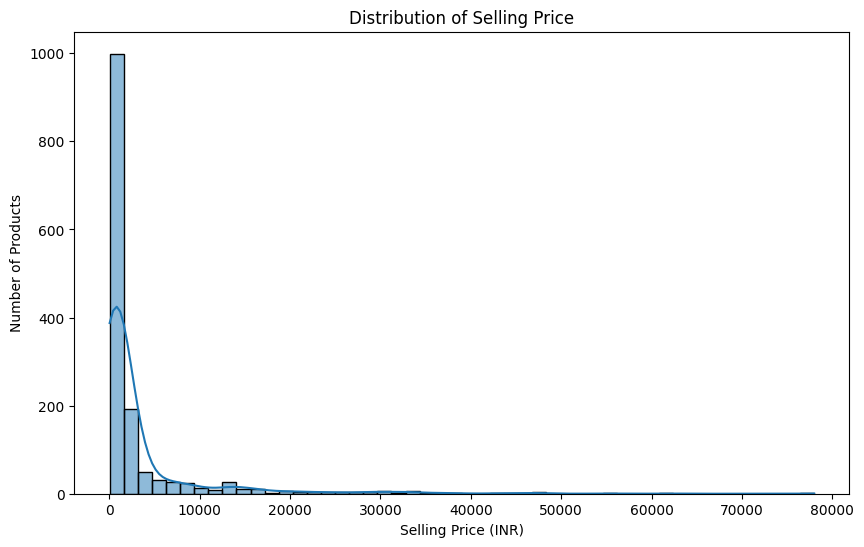

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['selling_price_inr'],
    bins=50,
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (INR)")
plt.ylabel("Number of Products")

plt.show()

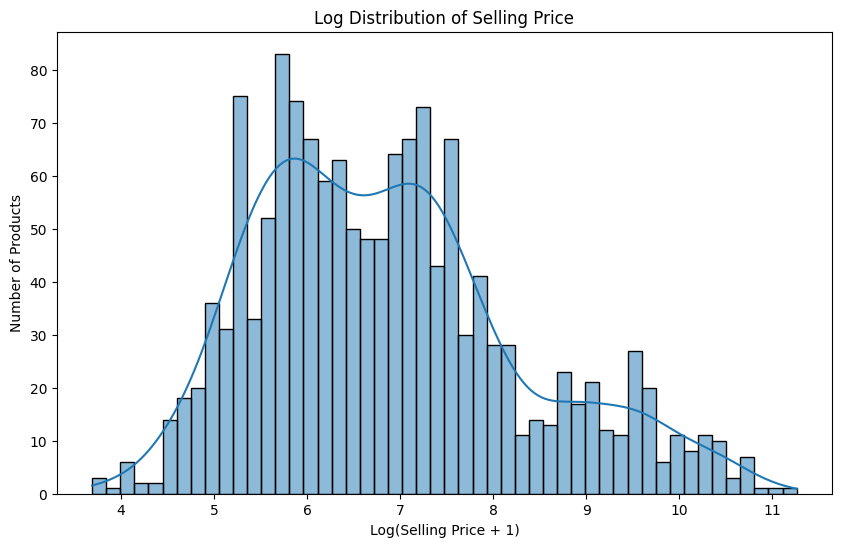

In [55]:
# Because prices are highly skewed, you can also use a log scale

plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(data['selling_price_inr']),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Selling Price")
plt.xlabel("Log(Selling Price + 1)")
plt.ylabel("Number of Products")

plt.show()

### Profit distribution

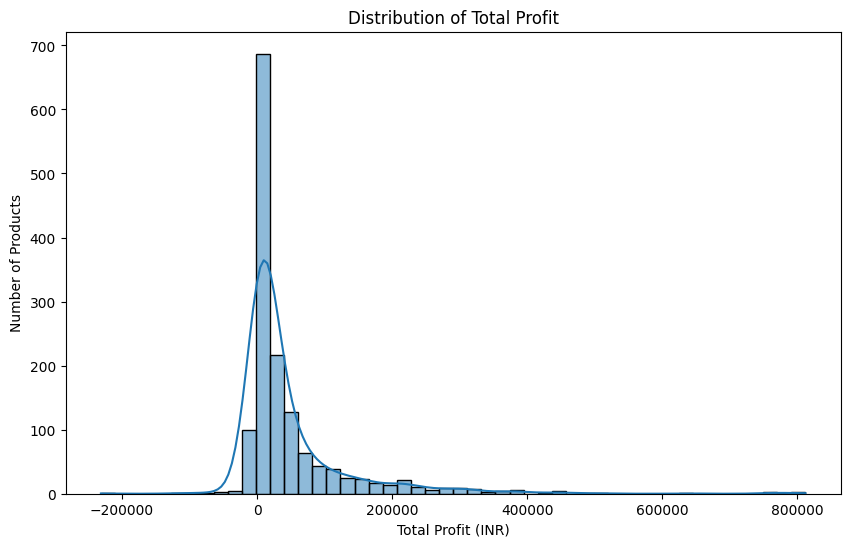

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['total_profit_inr'],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Profit")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Number of Products")

plt.show()

### Rating distribution

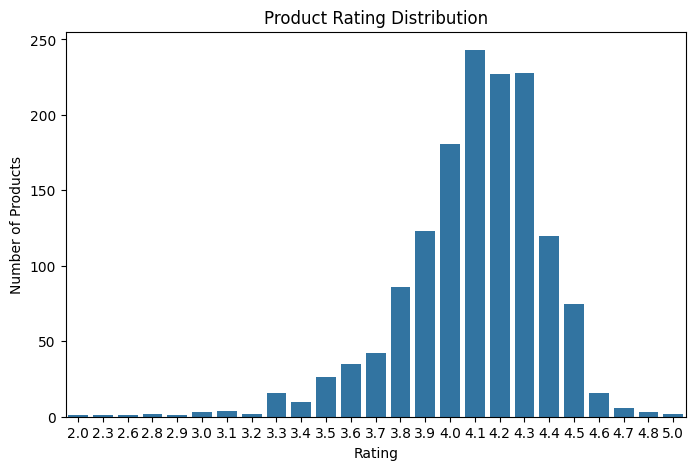

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='rating'
)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

### Discount analysis

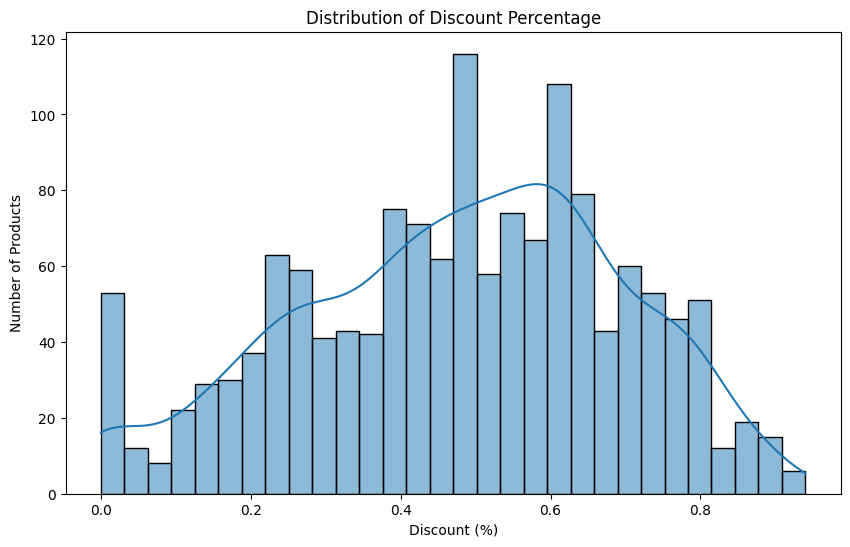

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['discount_percentage'],
    bins=30,
    kde=True
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")

plt.show()

### Profit margin distribution

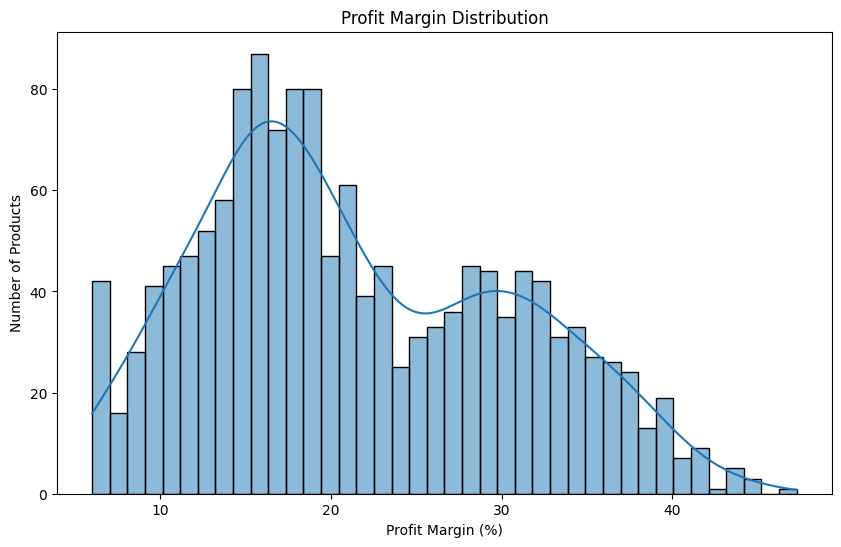

In [59]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['profit_margin_pct'],
    bins=40,
    kde=True
)

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Products")

plt.show()

### Correlation analysis

In [60]:
numeric_cols = [
    'mrp_inr',
    'selling_price_inr',
    'cost_price_inr',
    'profit_margin_pct',
    'stock_quantity',
    'avg_delivery_days',
    'return_rate_pct',
    'total_orders',
    'total_units_sold',
    'gross_revenue_inr',
    'net_revenue_inr',
    'total_profit_inr'
]

corr = data[numeric_cols].corr()

corr

,mrp_inr,selling_price_inr,cost_price_inr,profit_margin_pct,stock_quantity,avg_delivery_days,return_rate_pct,total_orders,total_units_sold,gross_revenue_inr,net_revenue_inr,total_profit_inr
mrp_inr,1.000000,0.961708,0.956784,-0.140707,0.034145,-0.033543,-0.038327,-0.293950,-0.292952,0.809969,0.812532,0.508276
selling_price_inr,0.961708,1.000000,0.995970,-0.134038,0.031367,-0.023269,-0.043933,-0.288976,-0.287957,0.861274,0.864071,0.553302
cost_price_inr,0.956784,0.995970,1.000000,-0.172840,0.027535,-0.020589,-0.040174,-0.275880,-0.274853,0.862628,0.866140,0.497786
profit_margin_pct,-0.140707,-0.134038,-0.172840,1.000000,0.017008,0.012723,-0.005973,-0.148478,-0.149086,-0.145411,-0.145962,0.267551
stock_quantity,0.034145,0.031367,0.027535,0.017008,1.000000,-0.006743,-0.032238,-0.002723,-0.003440,0.040842,0.039355,0.058046
avg_delivery_days,-0.033543,-0.023269,-0.020589,0.012723,-0.006743,1.000000,0.008690,0.047657,0.047818,-0.005682,-0.006618,-0.027380
return_rate_pct,-0.038327,-0.043933,-0.040174,-0.005973,-0.032238,0.008690,1.000000,-0.005907,-0.005948,-0.043687,-0.050309,-0.077596
total_orders,-0.293950,-0.288976,-0.275880,-0.148478,-0.002723,0.047657,-0.005907,1.000000,0.998476,-0.138857,-0.139569,-0.143290
total_units_sold,-0.292952,-0.287957,-0.274853,-0.149086,-0.003440,0.047818,-0.005948,0.998476,1.000000,-0.136988,-0.137548,-0.141021
gross_revenue_inr,0.809969,0.861274,0.862628,-0.145411,0.040842,-0.005682,-0.043687,-0.138857,-0.136988,1.000000,0.999068,0.660294


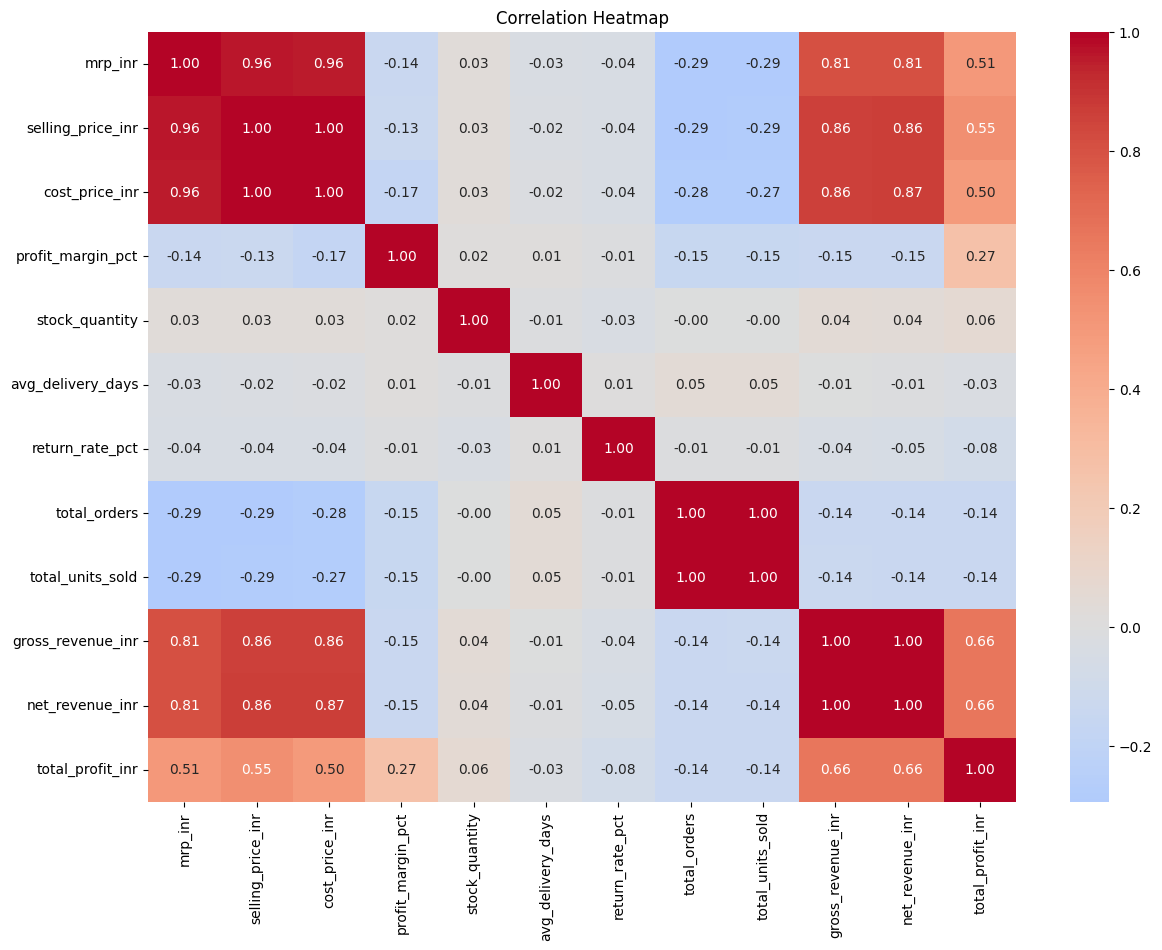

In [61]:
# Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

### Profit vs Revenue

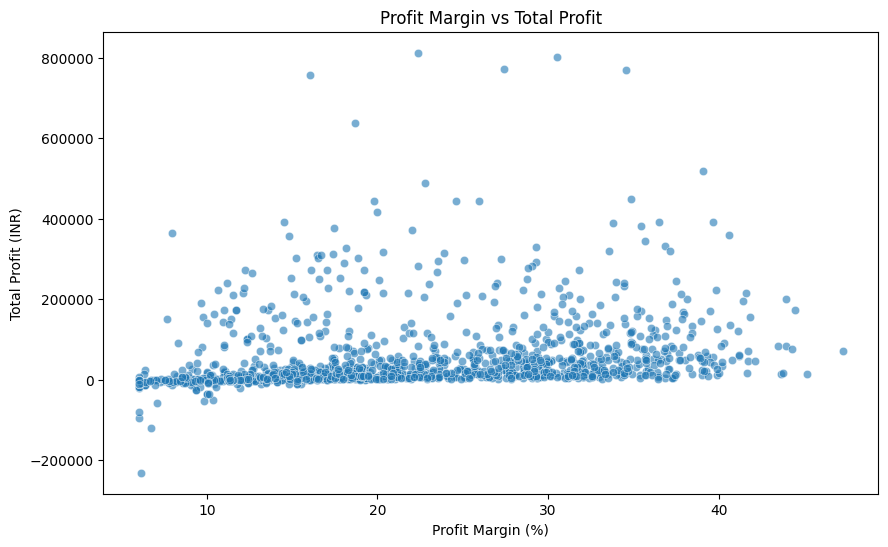

In [62]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='profit_margin_pct',
    y='total_profit_inr',
    alpha=0.6
)

plt.title("Profit Margin vs Total Profit")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Total Profit (INR)")

plt.show()

### Category-wise analysis

In [63]:
category_analysis = data.groupby('main_category').agg(
    products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    total_revenue=('net_revenue_inr', 'sum'),
    total_profit=('total_profit_inr', 'sum')
).sort_values(
    'total_profit',
    ascending=False
)

category_analysis

,products,avg_rating,total_revenue,total_profit
main_category,,,,
Home&Kitchen,447,4.040716,1.333723e+08,34956718.68
Electronics,522,4.079502,3.570980e+08,26307325.34
Computers&Accessories,447,4.154362,7.037908e+07,7352653.69
OfficeProducts,31,4.309677,2.436353e+06,589379.32
MusicalInstruments,2,3.900000,6.463169e+05,89373.38
Car&Motorbike,1,3.800000,2.310524e+05,48049.55
Health&PersonalCare,1,4.000000,1.439429e+05,41990.05
HomeImprovement,2,4.250000,1.796926e+05,29719.88
Toys&Games,1,4.300000,4.818846e+04,14598.90


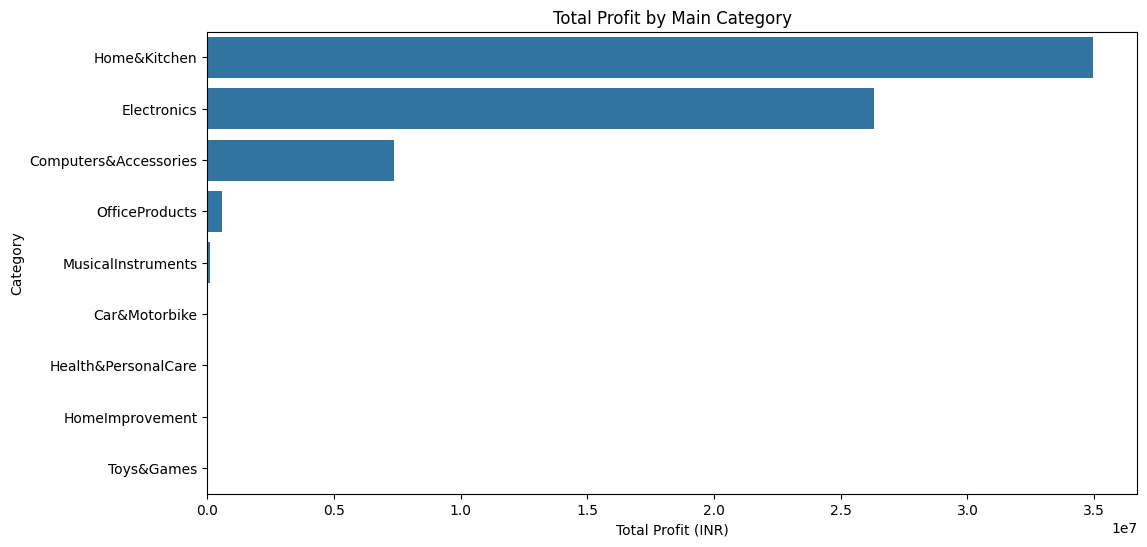

In [64]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_analysis.reset_index(),
    x='total_profit',
    y='main_category'
)

plt.title("Total Profit by Main Category")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Category")

plt.show()

### Top 10 brands by profit

In [65]:
brand_analysis = data.groupby('brand').agg(
    products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    total_revenue=('net_revenue_inr', 'sum'),
    total_profit=('total_profit_inr', 'sum')
).sort_values(
    'total_profit',
    ascending=False
)

top_brands = brand_analysis.head(10)

top_brands

,products,avg_rating,total_revenue,total_profit
brand,,,,
Redmi,26,4.053846,43151857.39,4123582.52
OnePlus,13,4.184615,43339801.61,3572103.26
Samsung,35,4.200000,46529690.48,3541424.58
Philips,18,4.261111,10215346.27,2905435.14
iQOO,14,4.157143,30929154.74,2396024.06
Bajaj,26,4.080769,8827892.92,2361717.95
Crompton,15,4.020000,6542668.89,1930145.75
MI,21,4.271429,22845726.11,1876655.30
LG,6,4.300000,13702820.12,1564507.19


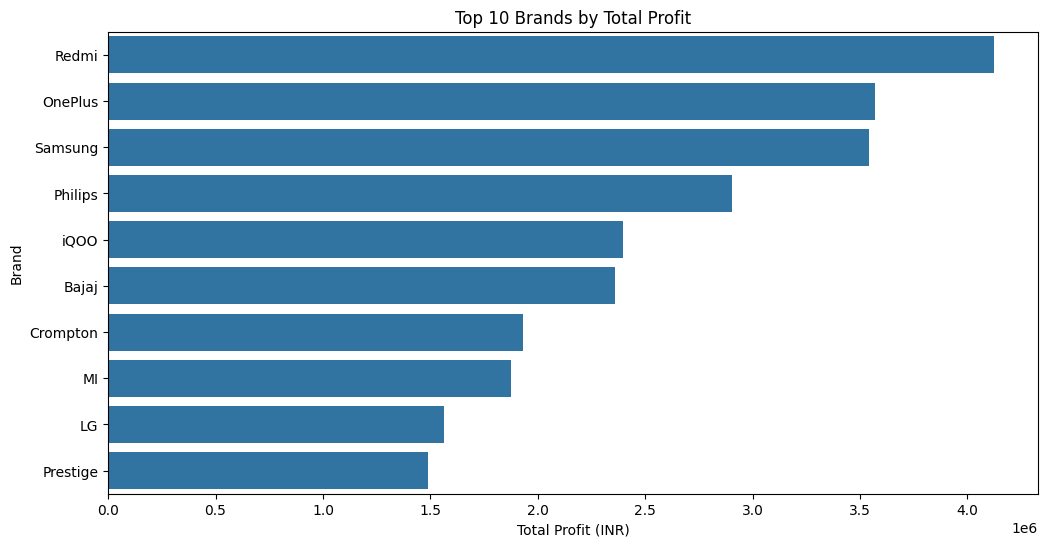

In [66]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_brands.reset_index(),
    x='total_profit',
    y='brand'
)

plt.title("Top 10 Brands by Total Profit")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Brand")

plt.show()

### Warehouse region analysis

In [67]:
region_analysis = data.groupby('warehouse_region').agg(
    products=('product_id', 'count'),
    orders=('total_orders', 'sum'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_delivery=('avg_delivery_days', 'mean')
).sort_values(
    'profit',
    ascending=False
)

region_analysis

,products,orders,revenue,profit,avg_delivery
warehouse_region,,,,,
South,398,75741,1.484060e+08,21119786.12,3.726131
North,360,66151,1.393721e+08,16546833.44,3.988889
West,332,65903,1.299453e+08,16249713.40,3.719880
East,220,42455,9.347943e+07,10511863.53,3.645455
Central,144,27172,5.333208e+07,5001612.30,4.006944


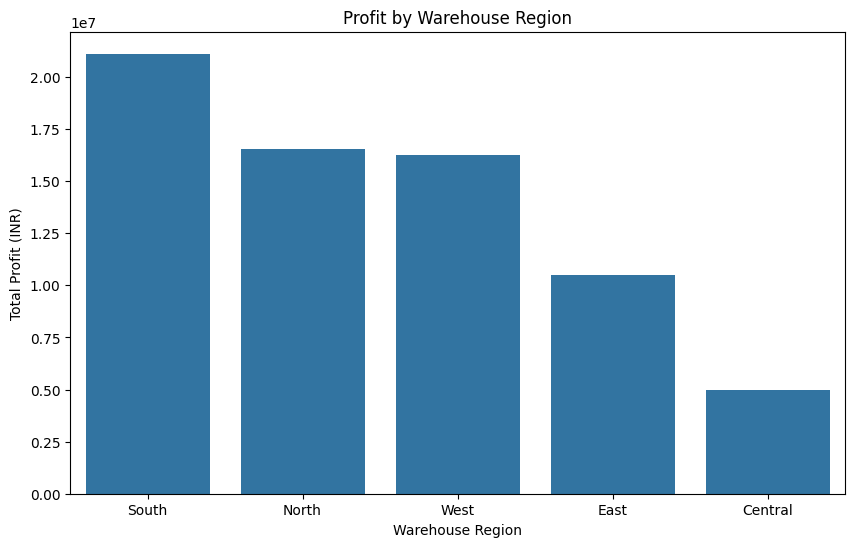

In [68]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis.reset_index(),
    x='warehouse_region',
    y='profit'
)

plt.title("Profit by Warehouse Region")
plt.xlabel("Warehouse Region")
plt.ylabel("Total Profit (INR)")

plt.show()

### Fulfilment type analysis

In [69]:
fulfilment_analysis = data.groupby('fulfilment_type').agg(
    products=('product_id', 'count'),
    orders=('total_orders', 'sum'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_delivery=('avg_delivery_days', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean')
)

fulfilment_analysis

,products,orders,revenue,profit,avg_delivery,avg_return_rate
fulfilment_type,,,,,,
FBA,727,140924,2.761421e+08,34441934.14,3.552957,4.915089
Prime,302,54558,1.149892e+08,14238267.83,1.470199,5.020629
Seller-Fulfilled,425,81940,1.734035e+08,20749606.82,5.896471,5.049012


### Seasonal products

In [70]:
seasonal_analysis = data.groupby('is_seasonal_product').agg(
    products=('product_id', 'count'),
    revenue=('net_revenue_inr', 'sum'),
    profit=('total_profit_inr', 'sum'),
    avg_rating=('rating', 'mean')
)

seasonal_analysis

,products,revenue,profit,avg_rating
is_seasonal_product,,,,
False,482,7.383674e+07,8121445.99,4.162241
True,972,4.906981e+08,61308362.80,4.062243


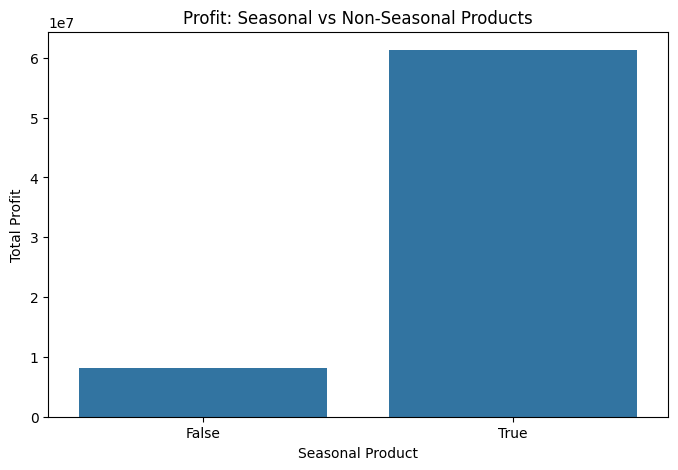

In [71]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_analysis.reset_index(),
    x='is_seasonal_product',
    y='profit'
)

plt.title("Profit: Seasonal vs Non-Seasonal Products")
plt.xlabel("Seasonal Product")
plt.ylabel("Total Profit")

plt.show()

### Outlier analysis

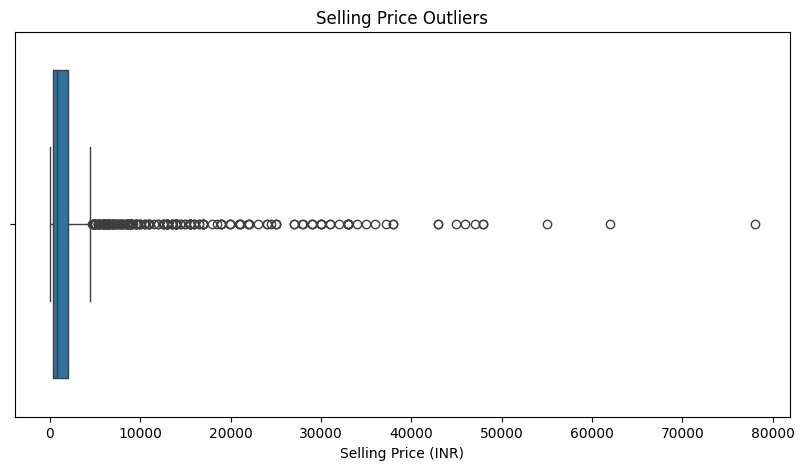

In [72]:
# Boxplot for selling price:

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=data['selling_price_inr']
)

plt.title("Selling Price Outliers")
plt.xlabel("Selling Price (INR)")

plt.show()

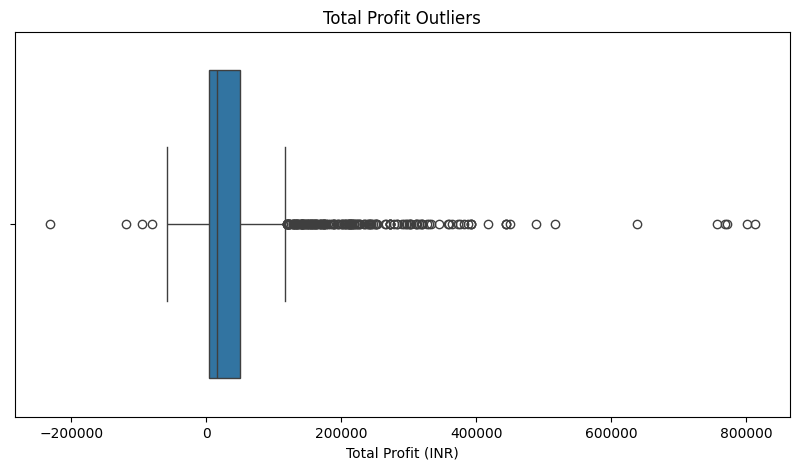

In [73]:
# Profit

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=data['total_profit_inr']
)

plt.title("Total Profit Outliers")
plt.xlabel("Total Profit (INR)")

plt.show()

### Top products by profit

In [74]:
top_products = data[
    [
        'product_name',
        'brand',
        'main_category',
        'selling_price_inr',
        'total_orders',
        'net_revenue_inr',
        'total_profit_inr'
    ]
].sort_values(
    'total_profit_inr',
    ascending=False
).head(10)

top_products

,product_name,brand,main_category,selling_price_inr,total_orders,net_revenue_inr,total_profit_inr
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,OnePlus,Electronics,32999.0,134,5131698.89,812315.86
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,LG,Home&Kitchen,42990.0,70,3488883.19,801677.74
1241,Usha Janome Dream Stitch Automatic Zig-Zag Ele...,Usha,Home&Kitchen,9799.0,273,3355272.06,771397.88
1297,AMERICAN MICRONIC- Imported Wet & Dry Vacuum C...,AMERICAN,Home&Kitchen,8886.0,236,2558139.70,768779.56
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,OnePlus,Electronics,61999.0,84,6406343.19,756617.51
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,MI,Electronics,46999.0,79,4397617.27,638596.61
1348,Crompton Solarium Qube 15-L 5 Star Rated Stora...,Crompton,Home&Kitchen,7799.0,174,1493866.25,517261.80
124,Redmi 126 cm (50 inches) 4K Ultra HD Android S...,Redmi,Electronics,32999.0,77,2774728.49,488296.96
1182,"Coway Professional Air Purifier for Home, Long...",Coway,Home&Kitchen,14400.0,125,1947402.91,449906.52
1306,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,ECOVACS,Home&Kitchen,27900.0,59,2148726.81,444667.47


### Top products by revenue

In [75]:
top_revenue_products = data[
    [
        'product_name',
        'brand',
        'main_category',
        'selling_price_inr',
        'total_orders',
        'net_revenue_inr',
        'total_profit_inr'
    ]
].sort_values(
    'net_revenue_inr',
    ascending=False
).head(10)

top_revenue_products

,product_name,brand,main_category,selling_price_inr,total_orders,net_revenue_inr,total_profit_inr
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Sony,Electronics,77990.0,97,8568651.16,-231326.62
216,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,OnePlus,Electronics,42999.0,127,6415008.80,151429.08
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,OnePlus,Electronics,61999.0,84,6406343.19,756617.51
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,OnePlus,Electronics,32999.0,134,5131698.89,812315.86
197,MI 108 cm (43 inches) 5A Series Full HD Smart ...,MI,Electronics,24999.0,162,4587727.41,272629.47
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,MI,Electronics,46999.0,79,4397617.27,638596.61
386,"OPPO A74 5G (Fantastic Purple,6GB RAM,128GB St...",OPPO,Electronics,15490.0,230,4367735.62,391922.68
533,"OnePlus 10T 5G (Moonstone Black, 8GB RAM, 128G...",OnePlus,Electronics,44999.0,79,4265509.65,222180.23
278,Mi 100 cm (40 inches) Horizon Edition Full HD ...,Mi,Electronics,21999.0,162,4022221.27,226578.24
410,"OnePlus 10R 5G (Forest Green, 8GB RAM, 128GB S...",OnePlus,Electronics,34999.0,86,3860319.74,154955.52


# Prediction model

In [76]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

### Select features

In [77]:
target = "total_units_sold"

features = [
    "selling_price_inr",
    "mrp_inr",
    "cost_price_inr",
    "discount_percentage",
    "rating",
    "rating_count",
    "profit_margin_pct",
    "stock_quantity",
    "avg_delivery_days",
    "return_rate_pct",
    "is_seasonal_product",
    "product_age_days",
    "warehouse_region",
    "fulfilment_type",
    "demand_tier",      # remove if demand_tier is derived from units sold (leakage)
    "main_category",
    "brand"
]

# One row per product, so the same product can't be in both train and test
model_df = data.drop_duplicates("product_id")

X = model_df[features].copy()
y = model_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1340, 17)
y shape: (1340,)


### Train-test split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1072, 17)
Testing : (268, 17)


### Separate numerical and categorical features

In [79]:
numeric_features = X.select_dtypes(include=["int64", "float64", "Int64", "bool"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['selling_price_inr', 'mrp_inr', 'cost_price_inr', 'discount_percentage', 'rating', 'rating_count', 'profit_margin_pct', 'stock_quantity', 'avg_delivery_days', 'return_rate_pct', 'is_seasonal_product', 'product_age_days']
Categorical: ['warehouse_region', 'fulfilment_type', 'demand_tier', 'main_category', 'brand']


### Preprocessing

In [80]:
# For Linear/Ridge, scaling is useful.

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Evaluation function

In [81]:
def evaluate_model(name, model, X_test, y_test):
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### ML Models

In [82]:
#------------------Baseline--------------------------------------------------
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_result = evaluate_model( "Baseline", baseline, X_test, y_test)

#---------------Linear Regression--------------------------------------------
linear_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_result = evaluate_model("Linear Regression", linear_model, X_test, y_test)

#---------------Ridge Regression--------------------------------------------
ridge_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_result = evaluate_model("Ridge Regression", ridge_model, X_test, y_test)

#---------------Random Forest--------------------------------------------
rf_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result = evaluate_model("Random Forest", rf_model, X_test, y_test)

#---------------LightGBM-------------------------------------------------
lgbm_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_result = evaluate_model("LightGBM", lgbm_model, X_test, y_test)


Baseline
----------------------------------------
MAE  : 123.52
RMSE : 169.42
R²   : -0.0020

Linear Regression
----------------------------------------
MAE  : 100.24
RMSE : 140.09
R²   : 0.3150

Ridge Regression
----------------------------------------
MAE  : 93.33
RMSE : 133.18
R²   : 0.3809

Random Forest
----------------------------------------
MAE  : 79.69
RMSE : 121.35
R²   : 0.4860

LightGBM
----------------------------------------
MAE  : 84.58
RMSE : 125.04
R²   : 0.4543


### Compare all models

In [83]:
results = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    rf_result,
    lgbm_result
])

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Random Forest,79.689701,121.346565,0.486009
4,LightGBM,84.580843,125.036609,0.454274
2,Ridge Regression,93.325306,133.177572,0.380897
1,Linear Regression,100.237132,140.089163,0.314970
0,Baseline,123.523509,169.424721,-0.001969


### K-Fold Cross Validation

In [84]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []
for name, model in [("Baseline", baseline), ("Linear Regression", linear_model), ("Ridge Regression", ridge_model), ("Random Forest", rf_model), ("LightGBM", lgbm_model)]:
    cv_results = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV MAE":  -cv_results["test_MAE"].mean(),
        "MAE std":  cv_results["test_MAE"].std(),
        "CV RMSE": -cv_results["test_RMSE"].mean(),
        "CV R2":    cv_results["test_R2"].mean(),
        "R2 std":   cv_results["test_R2"].std(),
    })
    print(f"{name}: R² per fold -> {np.round(cv_results['test_R2'], 3)}")

pd.DataFrame(cv_rows).round(3)


Baseline: R² per fold -> [-0.    -0.006 -0.    -0.    -0.007]
Linear Regression: R² per fold -> [0.283 0.334 0.117 0.167 0.091]
Ridge Regression: R² per fold -> [0.346 0.405 0.25  0.329 0.135]
Random Forest: R² per fold -> [0.562 0.573 0.482 0.541 0.378]
LightGBM: R² per fold -> [0.517 0.491 0.428 0.516 0.28 ]


,Model,CV MAE,MAE std,CV RMSE,CV R2,R2 std
0,Baseline,122.920,5.939,168.118,-0.003,0.003
1,Linear Regression,106.024,2.980,149.795,0.198,0.095
2,Ridge Regression,99.361,3.385,140.501,0.293,0.093
3,Random Forest,80.174,4.247,117.151,0.508,0.072
4,LightGBM,86.577,2.833,124.103,0.446,0.089


### Tune Random Forest

In [85]:
param_grid = {
    "model__n_estimators":      [500, 1000],
    "model__max_depth":         [None, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__max_features":      ["sqrt", 0.5],
}

rf_search = GridSearchCV(
    rf_model,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best CV MAE:", round(-rf_search.best_score_, 2))
print("\nBest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('model__', ''):<20} {v}")

rf_tuned = rf_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 78.75

Best parameters:
  max_depth            None
  max_features         0.5
  min_samples_leaf     1
  min_samples_split    10
  n_estimators         1000


In [86]:
# Cross-validate the tuned model on the same folds, then score the holdout.

cv_tuned = cross_validate(rf_tuned, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)

print("Tuned RF — R² per fold ->", np.round(cv_tuned["test_R2"], 3))
print(f"CV MAE : {-cv_tuned['test_MAE'].mean():.2f} ± {cv_tuned['test_MAE'].std():.2f}")
print(f"CV RMSE: {-cv_tuned['test_RMSE'].mean():.2f}")
print(f"CV R²  : {cv_tuned['test_R2'].mean():.3f} ± {cv_tuned['test_R2'].std():.3f}")

rf_tuned_result = evaluate_model("Random Forest (tuned)", rf_tuned, X_test, y_test)

Tuned RF — R² per fold -> [0.556 0.571 0.509 0.542 0.431]
CV MAE : 78.75 ± 3.23
CV RMSE: 115.69
CV R²  : 0.522 ± 0.050

Random Forest (tuned)
----------------------------------------
MAE  : 78.53
RMSE : 119.85
R²   : 0.4986


### Tune LightGBM

In [87]:
lgbm_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8
    ))
])


param_grid = {
    "model__n_estimators":       [600, 1200],
    "model__learning_rate":      [0.01, 0.03, 0.05],
    "model__num_leaves":         [7, 15, 31],
    "model__min_child_samples":  [5, 10, 20],
    "model__reg_lambda":         [0, 5],
}

lgbm_search = GridSearchCV(
    lgbm_pipe,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

print("Best CV MAE:", round(-lgbm_search.best_score_, 2))
print("\nBest parameters:")
for k, v in lgbm_search.best_params_.items():
    print(f"  {k.replace('model__', ''):<20} {v}")

lgbm_tuned = lgbm_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 79.09

Best parameters:
  learning_rate        0.01
  min_child_samples    10
  n_estimators         600
  num_leaves           7
  reg_lambda           5


In [88]:
cv_lgbm = cross_validate(lgbm_tuned, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)

print("Tuned LightGBM — R² per fold ->", np.round(cv_lgbm["test_R2"], 3))
print(f"CV MAE : {-cv_lgbm['test_MAE'].mean():.2f} ± {cv_lgbm['test_MAE'].std():.2f}")
print(f"CV RMSE: {-cv_lgbm['test_RMSE'].mean():.2f}")
print(f"CV R²  : {cv_lgbm['test_R2'].mean():.3f} ± {cv_lgbm['test_R2'].std():.3f}")

lgbm_tuned_result = evaluate_model("LightGBM (tuned)", lgbm_tuned, X_test, y_test)


Tuned LightGBM — R² per fold -> [0.553 0.568 0.523 0.571 0.385]
CV MAE : 79.09 ± 1.85
CV RMSE: 115.68
CV R²  : 0.520 ± 0.069

LightGBM (tuned)
----------------------------------------
MAE  : 78.83
RMSE : 119.78
R²   : 0.4992


RF wins because  dataset is too small (~930 rows per fold) for boosting — LightGBM's sequential error-correction ends up learning noise and overfitting the 430 sparse brand columns, while RF's independent trees average that noise away.

Best parameters:
  max_depth            None
  max_features         0.5
  min_samples_leaf     1
  min_samples_split    2
  n_estimators         500

# Predicting Value

In [89]:
import joblib

joblib.dump({
    "model":       rf_tuned,
    "features":    features,
    "numeric":     numeric_features,
    "categorical": categorical_features,
    "target":      target,
    "cv_mae":      -cv_tuned["test_MAE"].mean(),
    "cv_r2":       cv_tuned["test_R2"].mean(),
}, "rf_units_sold_model.joblib")

print("Saved -> rf_units_sold_model.joblib")

Saved -> rf_units_sold_model.joblib


In [90]:
# --- Predict for one new product ---

new_product = pd.DataFrame([{
    "selling_price_inr":    499.0,
    "mrp_inr":             1299.0,
    "cost_price_inr":       320.0,
    "discount_percentage":    0.62,
    "rating":                 4.3,
    "rating_count":         15000,
    "profit_margin_pct":     22.5,
    "stock_quantity":         500,
    "avg_delivery_days":        3,
    "return_rate_pct":        4.5,
    "is_seasonal_product":  False,
    "product_age_days":       365,
    "warehouse_region":  "North",
    "fulfilment_type":   data.fulfilment_type.mode()[0],
    "demand_tier":       "High",
    "main_category":     data.main_category.mode()[0],
    "brand":             data.brand.mode()[0],
}])[features]

units = rf_tuned.predict(new_product)[0]

print(f"Predicted units sold : {units:.0f}")
print(f"Estimated revenue    : ₹{units * 499:,.0f}")


Predicted units sold : 466
Estimated revenue    : ₹232,515


# Forecasting 

In [104]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [105]:
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_name,review_id,...,cat_l1,cat_l2,cat_l3,revenue_per_order,units_per_order,sell_through,active_days,units_per_day,product_age_days,discount_depth
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,484.400388,1.327586,0.518519,1087,0.566697,2392,0.636943
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,255.669277,1.384393,0.460577,1094,0.437843,2685,0.429799
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,348.368276,1.293103,0.266272,1072,0.209888,2831,0.895208
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,396.358768,1.299795,0.489938,1094,0.578611,2240,0.529328
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,185.662953,1.334262,0.360693,1091,0.439047,1824,0.614035


In [106]:
data["first_sale_date"] = pd.to_datetime(data["first_sale_date"])
data["last_sale_date"] = pd.to_datetime(data["last_sale_date"])

data = data.dropna(
    subset=[
        "first_sale_date",
        "last_sale_date",
        "total_units_sold",
        "gross_revenue_inr"
    ]
)

data[[
    "first_sale_date",
    "last_sale_date",
    "total_units_sold",
    "gross_revenue_inr"
]].head()

,first_sale_date,last_sale_date,total_units_sold,gross_revenue_inr
0,2023-01-06,2025-12-28,616,224761.78
1,2023-01-01,2025-12-30,479,88461.57
2,2023-01-18,2025-12-25,225,60616.08
3,2023-01-01,2025-12-30,633,193026.72
4,2023-01-04,2025-12-30,479,66653.00


### Create monthly forecasting data

In [108]:
# Since there are no individual sale dates, we distribute each product's total sales across its active sale window.

monthly_records = []

for _, row in data.iterrows():

    # Snap to month start so the first (partial) month is not skipped
    start = row["first_sale_date"].to_period("M").to_timestamp()
    end = row["last_sale_date"].to_period("M").to_timestamp()

    if pd.isna(start) or pd.isna(end):
        continue

    if end < start:
        continue

    # Monthly periods covered by the product
    months = pd.date_range(start=start, end=end, freq="MS")

    n_months = len(months)

    units_per_month = row["total_units_sold"] / n_months
    revenue_per_month = row["gross_revenue_inr"] / n_months

    for month in months:

        monthly_records.append({
            "month": month,
            "units": units_per_month,
            "revenue": revenue_per_month
        })

monthly_df = pd.DataFrame(monthly_records)

monthly_df.head()

,month,units,revenue
0,2023-01-01,17.111111,6243.382778
1,2023-02-01,17.111111,6243.382778
2,2023-03-01,17.111111,6243.382778
3,2023-04-01,17.111111,6243.382778
4,2023-05-01,17.111111,6243.382778


> **Note:** The dataset has no individual sale dates. The monthly series is built by spreading each product's total evenly across its active months, so it is smooth by construction. Low MAPE values below reflect that smoothing, not real forecasting skill.

### Aggregate monthly sales

In [109]:
monthly_sales = (
    monthly_df
    .groupby("month")
    .agg({
        "units": "sum",
        "revenue": "sum"
    })
    .sort_index()
)

monthly_sales.head()

,units,revenue
month,,
2023-01-01,9935.747993,1.511948e+07
2023-02-01,10153.445056,1.635113e+07
2023-03-01,10209.168207,1.684430e+07
2023-04-01,10222.655896,1.697553e+07
2023-05-01,10224.155896,1.697576e+07


In [110]:
# Check the complete time period

print("Start:", monthly_sales.index.min())
print("End:", monthly_sales.index.max())

print("Number of months:", len(monthly_sales))

Start: 2023-01-01 00:00:00
End: 2025-12-01 00:00:00
Number of months: 36


### Plot monthly units and revenue

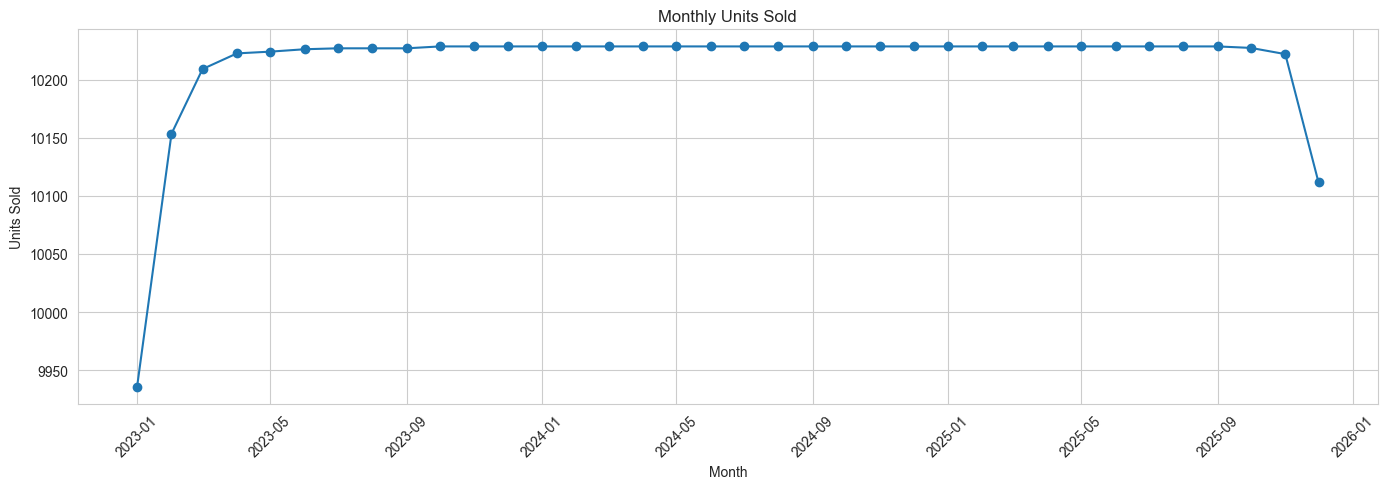

In [111]:
# Unit

plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index, monthly_sales["units"], marker="o")

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

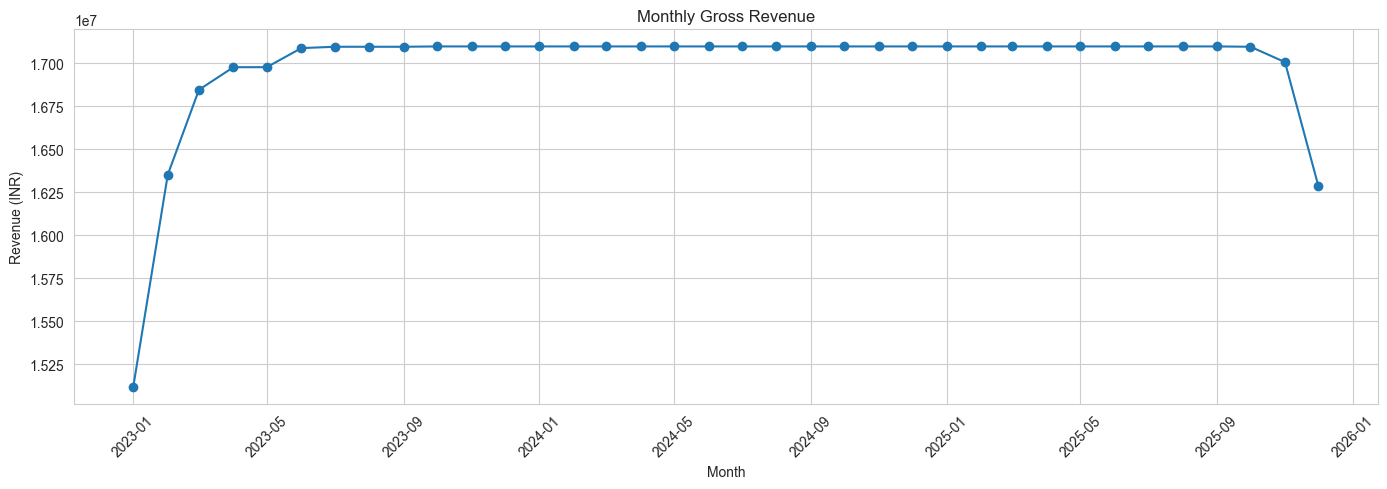

In [112]:
# Revenue

plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index, monthly_sales["revenue"], marker="o")

plt.title("Monthly Gross Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Stationarity test — ADF

In [113]:
# We'll use monthly units as the primary forecasting target.

units_series = monthly_sales["units"].asfreq("MS")

def adf_test(series, name="Series"):

    series = series.dropna()

    result = adfuller(series)

    print(f"ADF Test: {name}")
    print("-" * 40)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[4].items():
        print(f"   {key}: {value}")

    if result[1] < 0.05:
        print("\nResult: Stationary")
    else:
        print("\nResult: Non-stationary")


adf_test(units_series, "Monthly Units")

ADF Test: Monthly Units
----------------------------------------
ADF Statistic: 8.59939473159065
p-value: 1.0
Critical Values:
   1%: -3.639224104416853
   5%: -2.9512301791166293
   10%: -2.614446989619377

Result: Non-stationary


In [114]:
# If non-stationary, difference the series

units_diff = units_series.diff().dropna()

adf_test(units_diff, "Differenced Monthly Units")

ADF Test: Differenced Monthly Units
----------------------------------------
ADF Statistic: 7.45707552582539
p-value: 1.0
Critical Values:
   1%: -3.6461350877925254
   5%: -2.954126991123355
   10%: -2.6159676124885216

Result: Non-stationary


### ACF and PACF

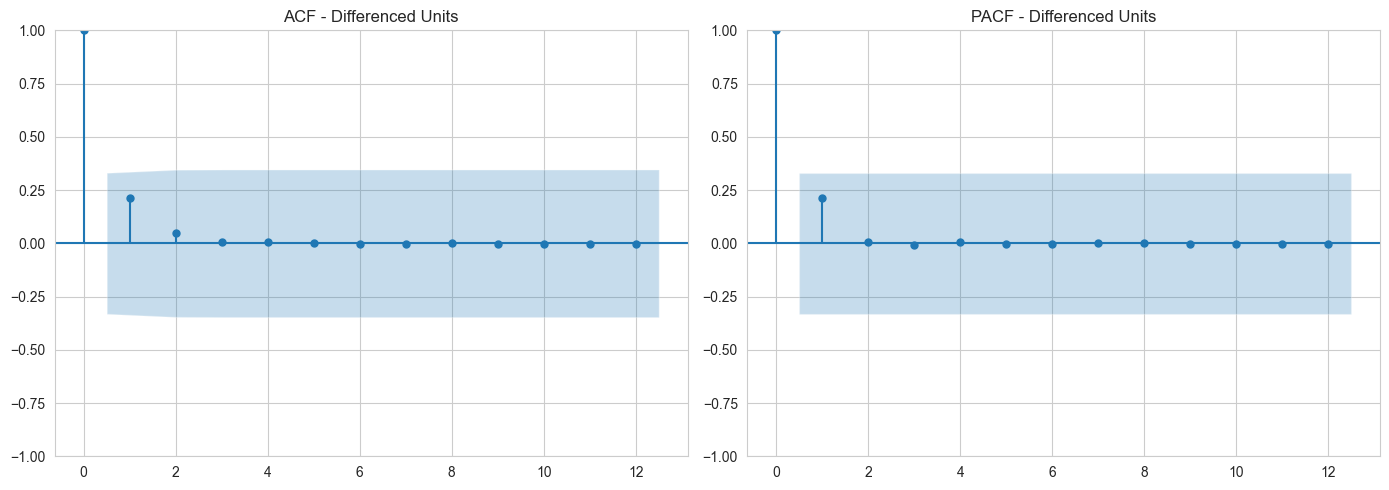

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    units_diff,
    lags=min(12, len(units_diff)//2),
    ax=axes[0]
)

plot_pacf(
    units_diff,
    lags=min(12, len(units_diff)//2),
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("ACF - Differenced Units")
axes[1].set_title("PACF - Differenced Units")

plt.tight_layout()
plt.show()

### Trend and seasonality decomposition

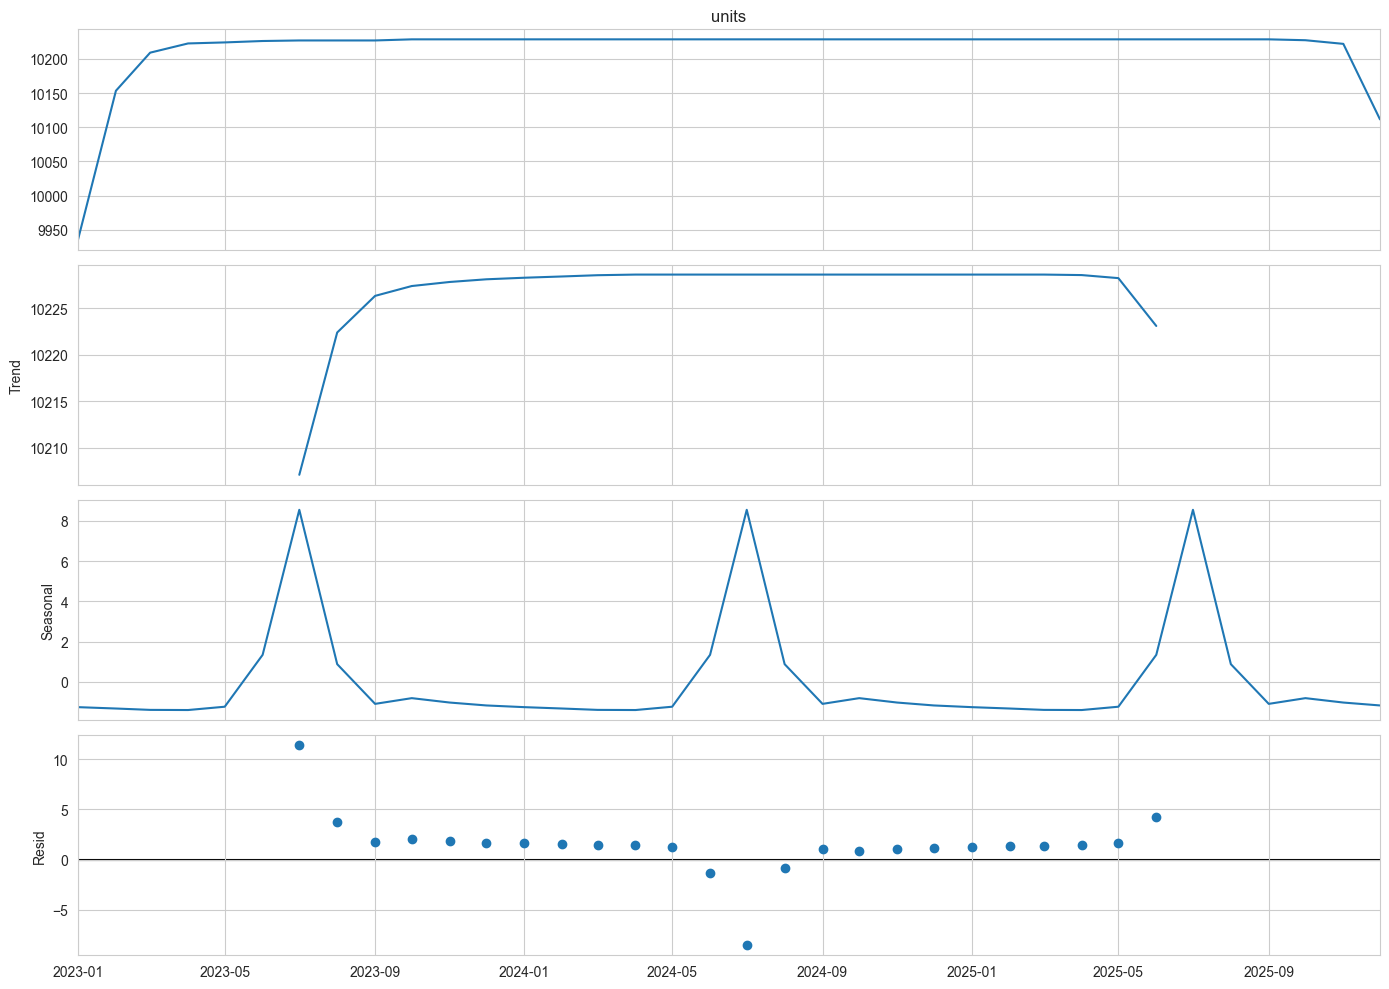

In [116]:
# Because we have monthly data, use a 12-month seasonal period.

decomposition = seasonal_decompose(units_series, model="additive", period=12)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### Train/test split

In [117]:
# We'll use the last 6 months as test data.

test_size = 6

train = units_series.iloc[:-test_size]
test = units_series.iloc[-test_size:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training period:
2023-01-01 00:00:00 to 2025-06-01 00:00:00

Testing period:
2025-07-01 00:00:00 to 2025-12-01 00:00:00


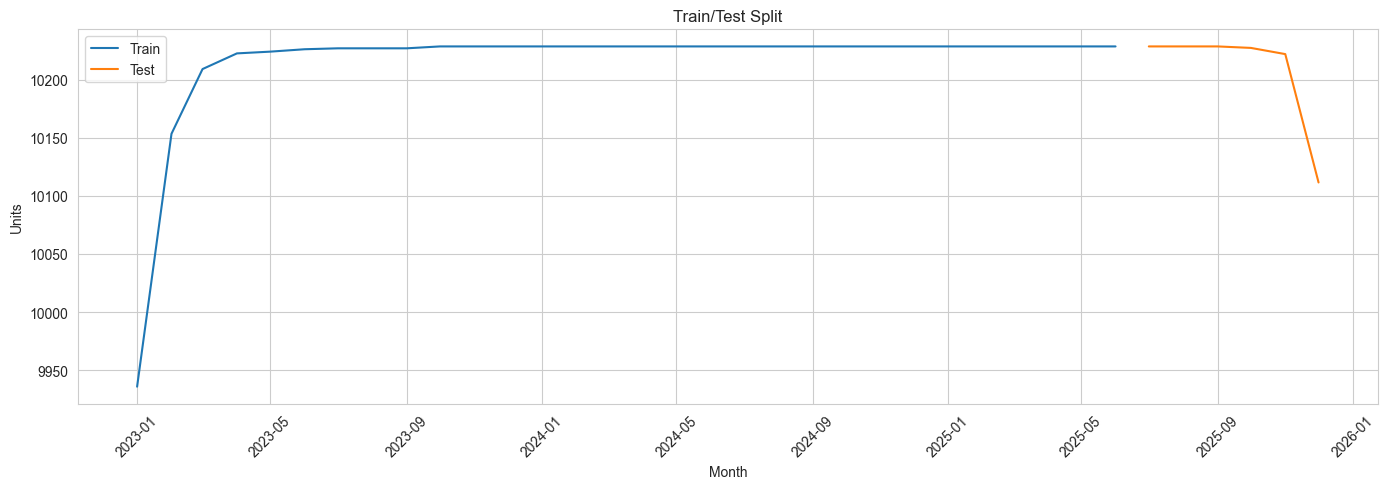

In [118]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Test")

plt.title("Train/Test Split")
plt.xlabel("Month")
plt.ylabel("Units")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Evaluation functions

In [119]:
def mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def rmse(y_true, y_pred):

    return np.sqrt(mean_squared_error(y_true,  y_pred))

### Naive baseline

In [120]:
# The naive model predicts that the next value will equal the last observed value.

naive_forecast = np.repeat(train.iloc[-1], len(test))

naive_mape = mape(test, naive_forecast)

naive_rmse = rmse(test, naive_forecast)

print("Naive Model")
print("MAPE:", round(naive_mape, 2), "%")
print("RMSE:", round(naive_rmse, 2))

Naive Model
MAPE: 0.21 %
RMSE: 47.89


### Moving Average baseline

In [121]:
window = 3

moving_average_forecast = []

history = list(train.values)

for i in range(len(test)):

    prediction = np.mean(history[-window:])

    moving_average_forecast.append(prediction)

    history.append(test.iloc[i])

moving_average_forecast = np.array(moving_average_forecast)

ma_mape = mape(test, moving_average_forecast)

ma_rmse = rmse(test, moving_average_forecast)

print("Moving Average Model")
print("MAPE:", round(ma_mape, 2), "%")
print("RMSE:", round(ma_rmse, 2))

Moving Average Model
MAPE: 0.2 %
RMSE: 46.81


### Holt-Winters model

In [122]:
holt_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

holt_fit = holt_model.fit(optimized=True)

holt_forecast = holt_fit.forecast(len(test))

holt_mape = mape(test, holt_forecast)

holt_rmse = rmse(test, holt_forecast)

print("Holt-Winters Model")
print("MAPE:", round(holt_mape, 2), "%")
print("RMSE:", round(holt_rmse, 2))

Holt-Winters Model
MAPE: 0.6 %
RMSE: 74.6


### SARIMA model

In [123]:
# A good starting configuration is: SARIMA(1,1,1)(1,1,1,12)

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_prediction = sarima_fit.get_forecast(steps=len(test))

sarima_forecast = sarima_prediction.predicted_mean

sarima_ci = sarima_prediction.conf_int()

sarima_mape = mape(test, sarima_forecast)

sarima_rmse = rmse(test, sarima_forecast)

print("SARIMA Model")
print("MAPE:", round(sarima_mape, 2), "%")
print("RMSE:", round(sarima_rmse, 2))

SARIMA Model
MAPE: 0.21 %
RMSE: 47.89


### Damped ETS model

In [124]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

ets_fit = ETSModel(
    train,
    error="add",
    trend="add",
    damped_trend=True
).fit(disp=False)

ets_forecast = ets_fit.forecast(len(test))

ets_mape = mape(test, ets_forecast)

ets_rmse = rmse(test, ets_forecast)

print("Damped ETS Model")
print("MAPE:", round(ets_mape, 2), "%")
print("RMSE:", round(ets_rmse, 2))

Damped ETS Model
MAPE: 0.33 %
RMSE: 54.48


### Random Forest Model

In [125]:
N_LAGS = 3

# Build lag features: predict each month from the 3 months before it
train_lagged = pd.DataFrame({"y": train})
for i in range(1, N_LAGS + 1):
    train_lagged[f"lag_{i}"] = train_lagged["y"].shift(i)
train_lagged = train_lagged.dropna()

rf_ts = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_ts.fit(train_lagged.drop(columns="y"), train_lagged["y"])

# Recursive forecast: each prediction feeds the next step
history = list(train.values)
rf_forecast = []

for _ in range(len(test)):
    x = np.array(history[-N_LAGS:][::-1]).reshape(1, -1)
    yhat = rf_ts.predict(x)[0]
    rf_forecast.append(yhat)
    history.append(yhat)

rf_forecast = np.array(rf_forecast)

rf_mape = mape(test, rf_forecast)

rf_rmse = rmse(test, rf_forecast)

print("Random Forest Model")
print("MAPE:", round(rf_mape, 2), "%")
print("RMSE:", round(rf_rmse, 2))


Random Forest Model
MAPE: 0.21 %
RMSE: 47.89


### Compare all models

In [126]:
results = pd.DataFrame({
    "Model": ["Naive", "Moving Average", "Holt-Winters", "SARIMA", "Random Forest", "Damped ETS"],

    "MAPE": [naive_mape, ma_mape, holt_mape, sarima_mape, rf_mape, ets_mape],

    "RMSE": [naive_rmse, ma_rmse, holt_rmse, sarima_rmse, rf_rmse, ets_rmse]
})

results = results.sort_values("RMSE").reset_index(drop=True)

results

,Model,MAPE,RMSE
0,Moving Average,0.200869,46.807362
1,SARIMA,0.205903,47.889538
2,Naive,0.205903,47.889570
3,Random Forest,0.205903,47.889570
4,Damped ETS,0.327641,54.478330
5,Holt-Winters,0.596779,74.598087


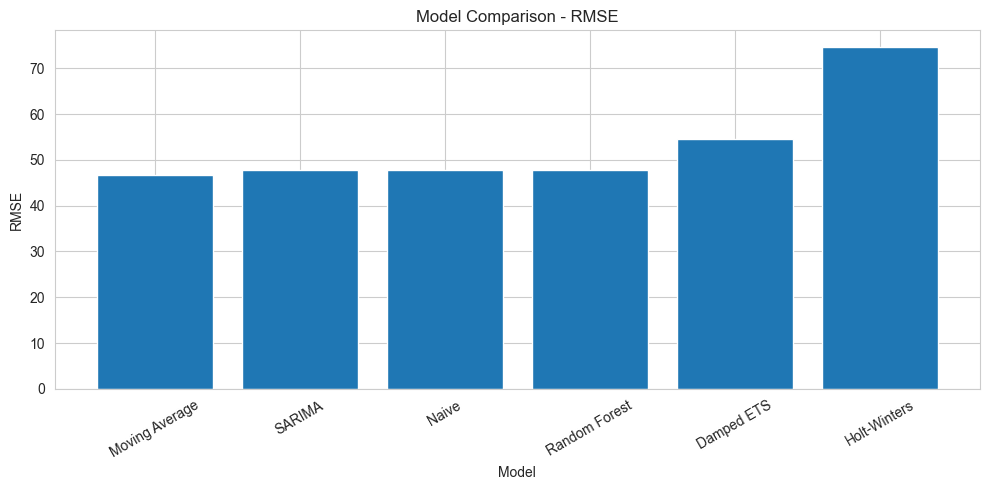

In [127]:
plt.figure(figsize=(10, 5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Compare actual vs predicted

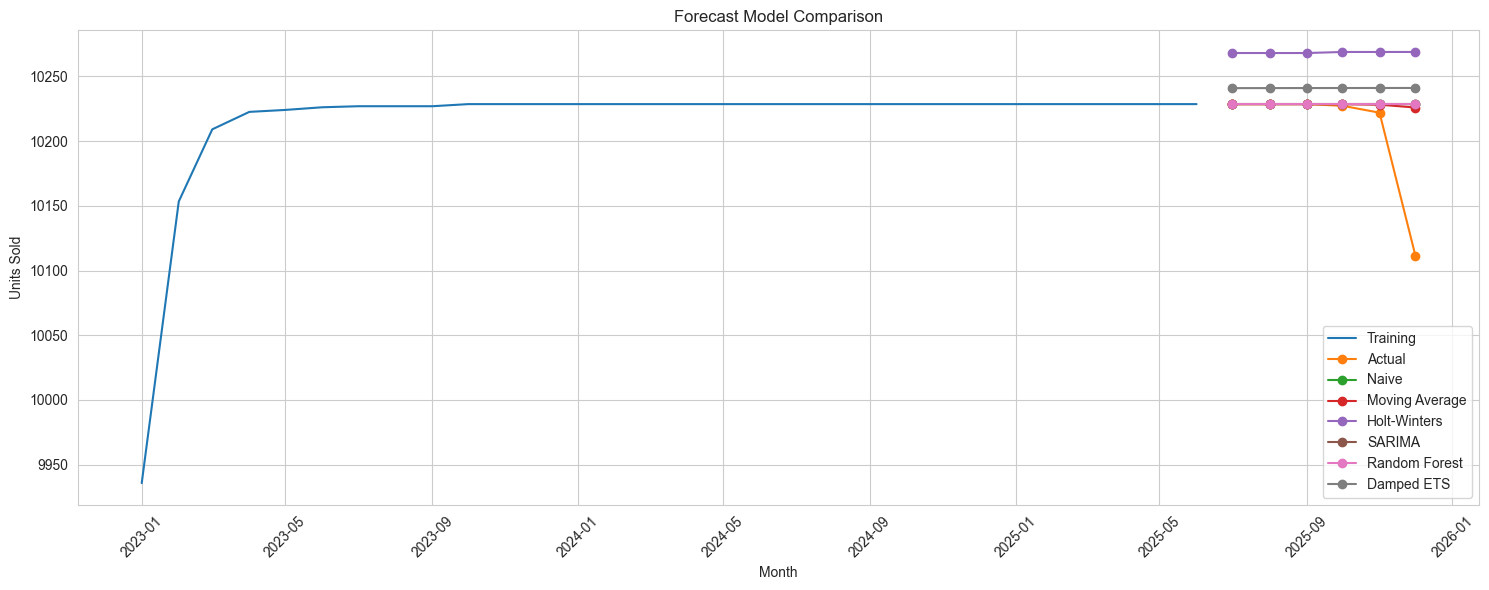

In [128]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, marker="o", label="Actual")

plt.plot(test.index, naive_forecast, marker="o", label="Naive")

plt.plot( test.index, moving_average_forecast, marker="o", label="Moving Average")

plt.plot(test.index, holt_forecast, marker="o", label="Holt-Winters")

plt.plot(test.index, sarima_forecast, marker="o", label="SARIMA")

plt.plot(test.index, rf_forecast, marker="o", label="Random Forest")

plt.plot(test.index, ets_forecast, marker="o", label="Damped ETS")

plt.title("Forecast Model Comparison")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### SARIMA confidence interval

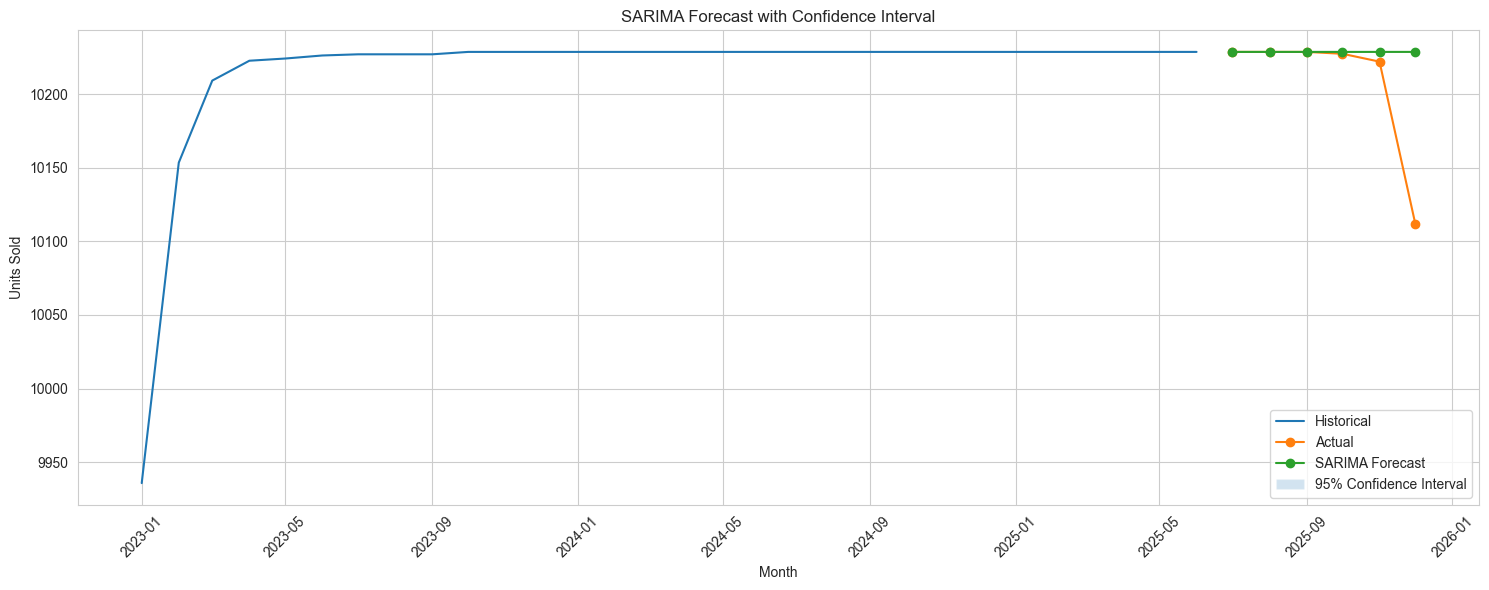

In [129]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train, label="Historical")

plt.plot(test.index, test, marker="o", label="Actual")

plt.plot(test.index, sarima_forecast, marker="o", label="SARIMA Forecast")

plt.fill_between(
    test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast with Confidence Interval")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Rolling-origin cross-validation

In [130]:
# This is important because you specifically wanted rolling-origin CV.

def rolling_origin_sarima(series, initial_train_size, horizon=1):

    predictions = []
    actuals = []

    for i in range(initial_train_size, len(series) - horizon + 1):

        train_data = series.iloc[:i]

        test_data = series.iloc[i:i + horizon]

        try:

            model = SARIMAX(
                train_data,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)

            forecast = fitted.forecast(horizon)

            predictions.extend(forecast.values)

            actuals.extend(test_data.values)

        except Exception as e:

            print("Error at iteration:", i, e)

    return (np.array(actuals), np.array(predictions))

In [131]:
initial_train_size = max(24, int(len(units_series) * 0.6))

cv_actual, cv_prediction = rolling_origin_sarima(
    units_series,
    initial_train_size=initial_train_size,
    horizon=1
)

cv_mape = mape(cv_actual, cv_prediction)

cv_rmse = rmse(cv_actual, cv_prediction)

print("Rolling-Origin SARIMA CV")
print("-------------------------")
print("MAPE:", round(cv_mape, 2), "%")
print("RMSE:", round(cv_rmse, 2))

Rolling-Origin SARIMA CV
-------------------------
MAPE: 0.09 %
RMSE: 29.94


### Plot rolling-origin CV

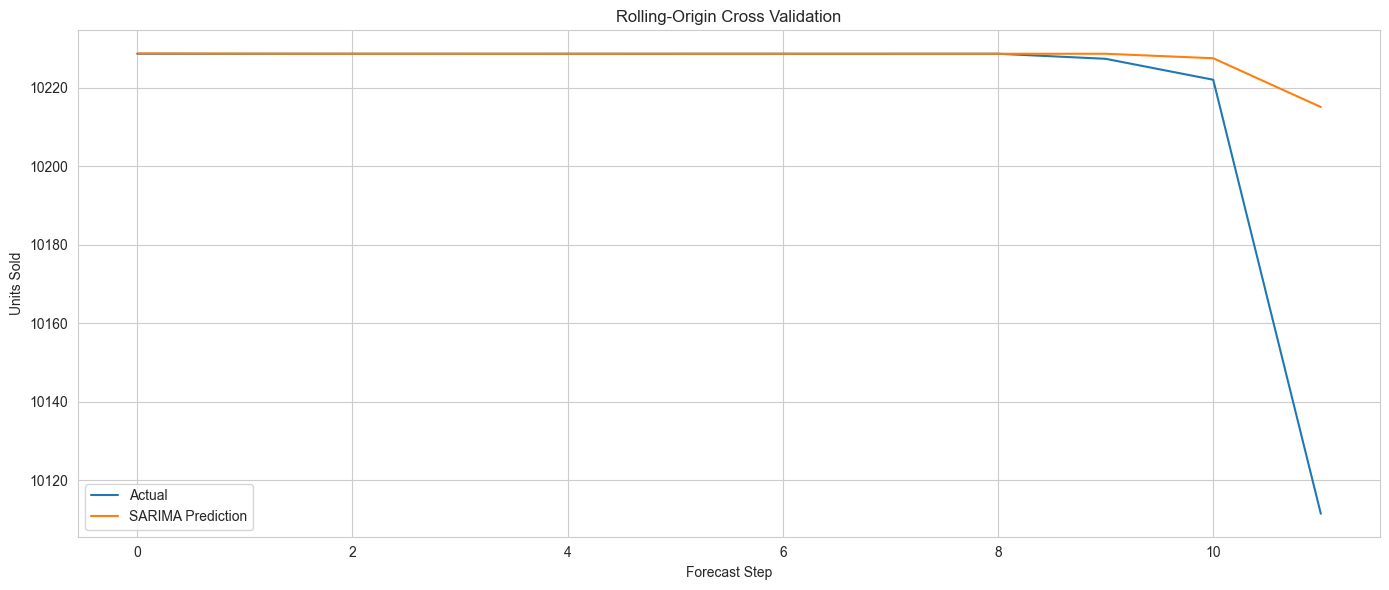

In [132]:
plt.figure(figsize=(14, 6))

plt.plot(cv_actual, label="Actual")

plt.plot(cv_prediction, label="SARIMA Prediction")

plt.title("Rolling-Origin Cross Validation")

plt.xlabel("Forecast Step")
plt.ylabel("Units Sold")

plt.legend()

plt.tight_layout()
plt.show()

### Train final Damped ETS model on all data
SARIMA(1,1,1)(1,1,1,12) produced exploding negative forecasts on only 36 months of data, so the final model is a damped-trend ETS, which is stable and gives proper prediction intervals.

In [133]:
# After evaluating the models, we train the final model using the entire historical dataset.

final_fit = ETSModel(
    units_series,
    error="add",
    trend="add",
    damped_trend=True
).fit(disp=False)

In [134]:
# Forecast next 6 months

forecast_periods = 6

future_start = units_series.index[-1] + pd.offsets.MonthBegin(1)
future_end   = units_series.index[-1] + pd.offsets.MonthBegin(forecast_periods)

future_frame = final_fit.get_prediction(start=future_start, end=future_end).summary_frame(alpha=0.05)

future_forecast = future_frame["mean"]

future_ci = future_frame[["pi_lower", "pi_upper"]]

print("Next 6 Months Forecast:")
print(future_forecast.round(0))

Next 6 Months Forecast:
2026-01-01    10232.0
2026-02-01    10232.0
2026-03-01    10232.0
2026-04-01    10232.0
2026-05-01    10232.0
2026-06-01    10232.0
Freq: MS, Name: mean, dtype: float64


### Final forecast plot

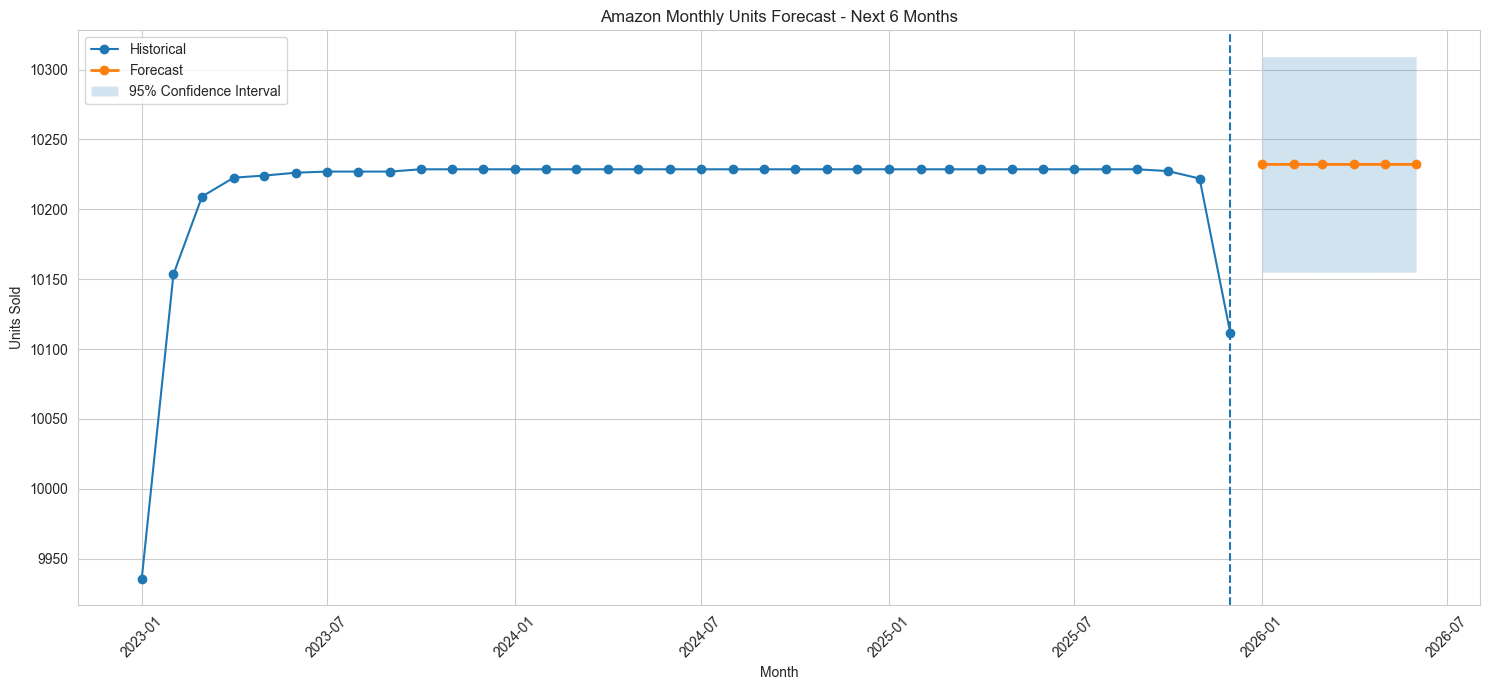

In [135]:
plt.figure(figsize=(15, 7))

plt.plot(
    units_series.index,
    units_series,
    marker="o",
    label="Historical"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    future_forecast.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    units_series.index[-1],
    linestyle="--"
)

plt.title(
    "Amazon Monthly Units Forecast - Next 6 Months"
)

plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Create final forecast table

In [136]:
forecast_table = pd.DataFrame({
    "Month": future_forecast.index,
    "Forecast_Units": future_forecast.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values
})

forecast_table["Forecast_Units"] = (forecast_table["Forecast_Units"].clip(lower=0))

forecast_table["Lower_CI"] = (forecast_table["Lower_CI"].clip(lower=0))

forecast_table["Upper_CI"] = (forecast_table["Upper_CI"].clip(lower=0))

forecast_table

,Month,Forecast_Units,Lower_CI,Upper_CI
0,2026-01-01,10232.132951,10154.930248,10309.335654
1,2026-02-01,10232.140990,10154.938286,10309.343693
2,2026-03-01,10232.147420,10154.944717,10309.350124
3,2026-04-01,10232.152565,10154.949861,10309.355269
4,2026-05-01,10232.156680,10154.953976,10309.359385
5,2026-06-01,10232.159973,10154.957268,10309.362678


# Business insights

### Top/bottom performing categories & brands

Top 5 categories
                        products   units       revenue       profit  \
main_category                                                        
Home&Kitchen                447   85276  1.333723e+08  34956718.68   
Electronics                 486  114813  3.414987e+08  25505311.82   
Computers&Accessories       369  114273  6.333977e+07   6755588.67   
OfficeProducts               31   12187  2.436353e+06    589379.32   

                       avg_rating  avg_return  margin_pct  
main_category                                              
Home&Kitchen                 4.04        5.05       26.21  
Electronics                  4.08        4.99        7.47  
Computers&Accessories        4.15        4.90       10.67  
OfficeProducts               4.31        4.68       24.19  

Bottom 5 categories
                        products   units       revenue       profit  \
main_category                                                        
Home&Kitchen                447   85276

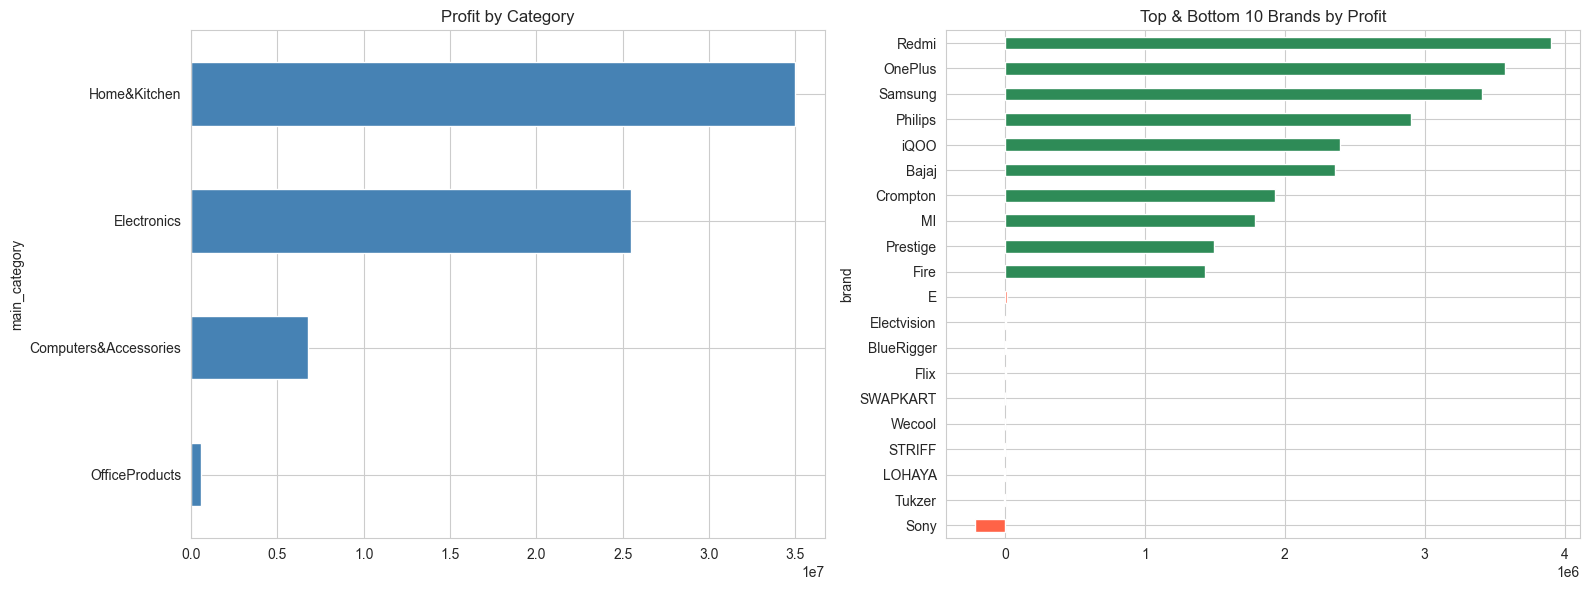

In [137]:
prod = data.drop_duplicates("product_id").copy()

def perf(df, key, min_n=3):
    t = (df.groupby(key)
           .agg(products=("product_id", "nunique"),
                units=("total_units_sold", "sum"),
                revenue=("net_revenue_inr", "sum"),
                profit=("total_profit_inr", "sum"),
                avg_rating=("rating", "mean"),
                avg_return=("return_rate_pct", "mean"))
           .query("products >= @min_n"))
    t["margin_pct"] = t.profit / t.revenue * 100
    return t.sort_values("profit", ascending=False).round(2)

cat_perf   = perf(prod, "main_category")
brand_perf = perf(prod, "brand")

print("Top 5 categories\n", cat_perf.head(5))
print("\nBottom 5 categories\n", cat_perf.tail(5))
print("\nTop 10 brands\n", brand_perf.head(10))
print("\nBottom 10 brands\n", brand_perf.tail(10))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
cat_perf["profit"].sort_values().plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Profit by Category")
pd.concat([brand_perf.head(10), brand_perf.tail(10)])["profit"].sort_values() \
  .plot.barh(ax=ax[1], color=["tomato"]*10 + ["seagreen"]*10)
ax[1].set_title("Top & Bottom 10 Brands by Profit")
plt.tight_layout(); plt.show()

### Optimal discount band by category

           main_category optimal_band   n  units_per_day  profit_per_product  \
0            Electronics        0-10%  17           0.19            96002.61   
1           Home&Kitchen       20-30%  59           0.16            86000.15   
2  Computers&Accessories       10-20%  16           0.24            32686.16   
3         OfficeProducts        0-10%  19           0.33            13302.01   

   margin  
0   15.05  
1   32.47  
2   19.39  
3   29.30  


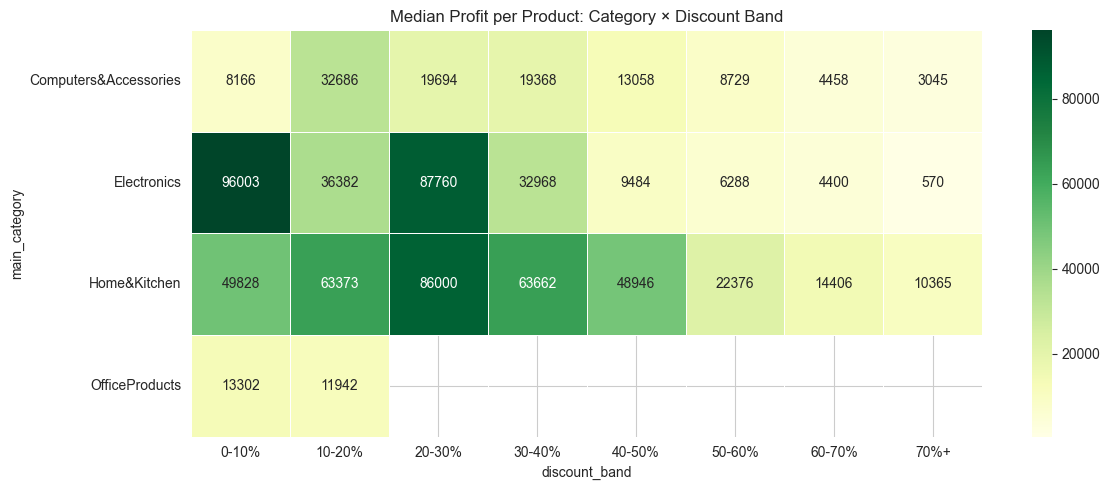

In [138]:
bins   = [0, .10, .20, .30, .40, .50, .60, .70, 1.0]
labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70%+"]
prod["discount_band"] = pd.cut(prod.discount_percentage, bins=bins, labels=labels, include_lowest=True)

band = (prod.groupby(["main_category", "discount_band"], observed=True)
            .agg(n=("product_id", "count"),
                 units_per_day=("units_per_day", "median"),
                 profit_per_product=("total_profit_inr", "median"),
                 margin=("profit_margin_pct", "median"))
            .reset_index()
            .query("n >= 5"))

optimal_band = (band.sort_values("profit_per_product", ascending=False)
                    .groupby("main_category").head(1)
                    .rename(columns={"discount_band": "optimal_band"})
                    .reset_index(drop=True))
print(optimal_band.round(2))

pivot = band.pivot(index="main_category", columns="discount_band", values="profit_per_product")
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGn", linewidths=.5)
plt.title("Median Profit per Product: Category × Discount Band")
plt.tight_layout(); plt.show()


### High return-rate products to flag

Flagged: 140 / 1340 | Revenue lost: ₹3,390,493
      product_id                                       product_name     brand  \
216   B095JQVC7N  OnePlus 138.7 cm (55 inches) U Series 4K LED S...   OnePlus   
278   B09HQSV46W  Mi 100 cm (40 inches) Horizon Edition Full HD ...        Mi   
387   B09T39K9YL  Redmi Note 11 Pro + 5G (Stealth Black, 6GB RAM...     Redmi   
1182  B08GJ57MKL  Coway Professional Air Purifier for Home, Long...     Coway   
501   B09QS9X9L8  Redmi Note 11 (Horizon Blue, 6GB RAM, 64GB Sto...     Redmi   
434   B07WHQWXL7  iQOO Z6 44W by vivo (Lumina Blue, 6GB RAM, 128...      iQOO   
481   B0B4F1YC3J  Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB ...   Samsung   
157   B088Z1YWBC  EGate i9 Pro-Max 1080p Native Full HD Projecto...     EGate   
1245  B09YLWT89W  Sure From Aquaguard Delight NXT RO+UV+UF+Taste...      Sure   
1415  B0756KCV5K  Prestige PIC 15.0+ 1900-Watt Induction Cooktop...  Prestige   
1238  B07DZ986Q2  Philips EasyTouch Plus Standing Garment Stea

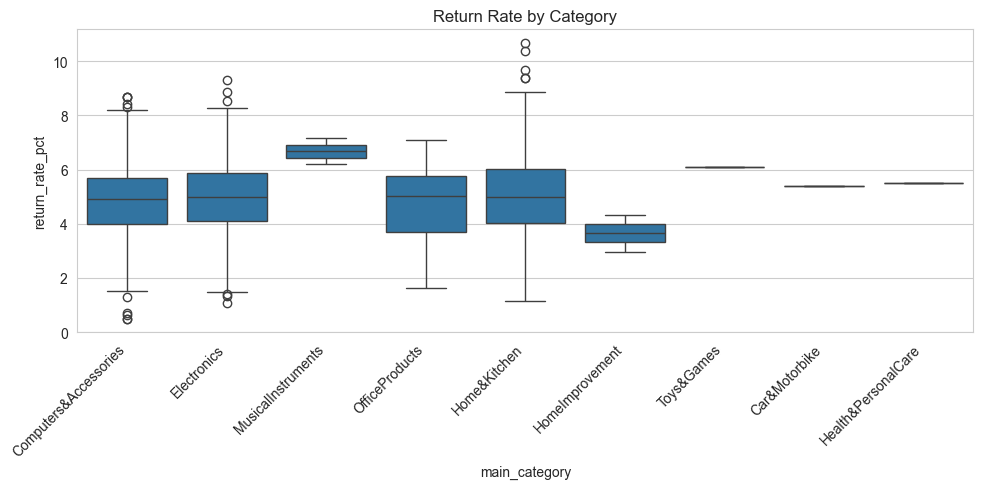

In [139]:
g = prod.groupby("main_category")["return_rate_pct"]
prod["cat_ret_p90"]  = g.transform(lambda s: s.quantile(.90))
prod["cat_ret_mean"] = g.transform("mean")
prod["high_return_flag"] = prod.return_rate_pct >= prod.cat_ret_p90
prod["return_loss_inr"]  = prod.gross_revenue_inr * prod.return_rate_pct / 100

flagged = (prod[prod.high_return_flag]
           [["product_id", "product_name", "brand", "main_category", "return_rate_pct",
             "cat_ret_mean", "rating", "fulfilment_type", "return_loss_inr"]]
           .sort_values("return_loss_inr", ascending=False))
flagged["product_name"] = flagged.product_name.str[:50]

print(f"Flagged: {len(flagged)} / {len(prod)} | Revenue lost: ₹{flagged.return_loss_inr.sum():,.0f}")
print(flagged.head(15).round(2))

print("\nFlag rate by brand (min 5 products)")
bf = prod.groupby("brand").agg(n=("product_id", "count"), flag_rate=("high_return_flag", "mean"))
print(bf.query("n >= 5").sort_values("flag_rate", ascending=False).head(10).round(2))

plt.figure(figsize=(10, 5))
sns.boxplot(data=prod, x="main_category", y="return_rate_pct")
plt.xticks(rotation=45, ha="right"); plt.title("Return Rate by Category")
plt.tight_layout(); plt.show()


### Stock vs forecasted demand → restock recommendations

Growth factor (next 3-month avg forecast / Dec-25 actual): 1.012
restock_action
Overstock         1201
Healthy             99
Restock             26
URGENT restock      14
Name: count, dtype: int64
      product_id                                       product_name  \
46    B002PD61Y4  D-Link DWA-131 300 Mbps Wireless Nano USB Adap...   
715   B07KR5P3YD  Zebronics Wired Keyboard and Mouse Combo with ...   
828   B08KHM9VBJ  Airtel AMF-311WW Data Card (Black), 4g Hotspot...   
1221  B00S9BSJC8  Philips Viva Collection HR1832/00 1.5-Litre400...   
102   B07DL1KC3H  Isoelite Remote Compatible for Samsung LED/LCD...   
804   B07NC12T2R  boAt Stone 650 10W Bluetooth Speaker with Upto...   
505   B084DTMYWK  Myvn 30W Warp/20W Dash Charging Usb Type C Cha...   
389   B08G28Z33M  realme Buds Classic Wired in Ear Earphones wit...   
1063  B07SRM58TP  AGARO Regal 800 Watts Handheld Vacuum Cleaner,...   
741   B09Z28BQZT  Amazon Basics Multipurpose Foldable Laptop Tab...   
676   B0819ZZK5K  San

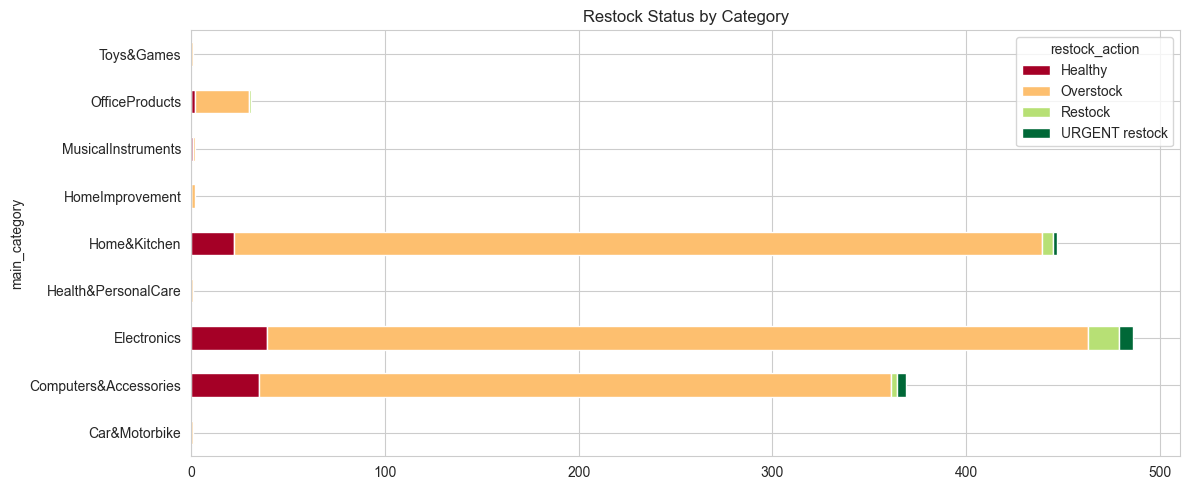

In [140]:
horizon_months   = 3
avg_fc           = forecast_table["Forecast_Units"].head(horizon_months).mean()
last_month_act   = units_series.iloc[-1]
growth           = avg_fc / last_month_act

lead_time_months = 1
safety_factor    = 0.2

prod["monthly_demand"]  = prod.units_per_day * 30 * growth
prod["horizon_demand"]  = prod.monthly_demand * horizon_months
prod["safety_stock"]    = prod.monthly_demand * lead_time_months * safety_factor
prod["reorder_point"]   = prod.monthly_demand * lead_time_months + prod.safety_stock
prod["months_of_cover"] = prod.stock_quantity / prod.monthly_demand.replace(0, np.nan)
prod["restock_qty"]     = (prod.horizon_demand + prod.safety_stock - prod.stock_quantity).clip(lower=0).round()

def action(r):
    if r.stock_quantity <= r.reorder_point:  return "URGENT restock"
    if r.stock_quantity <  r.horizon_demand: return "Restock"
    if r.months_of_cover > 12:               return "Overstock"
    return "Healthy"

prod["restock_action"] = prod.apply(action, axis=1)

print(f"Growth factor (next {horizon_months}-month avg forecast / Dec-25 actual): {growth:.3f}")
print(prod.restock_action.value_counts())

restock = (prod[prod.restock_action.isin(["URGENT restock", "Restock"])]
           [["product_id", "product_name", "main_category", "warehouse_region",
             "stock_quantity", "monthly_demand", "months_of_cover", "restock_qty", "restock_action"]]
           .sort_values(["restock_action", "months_of_cover"], ascending=[False, True]))
restock["product_name"] = restock.product_name.str[:50]
print(restock.head(20).round(1))

print("\nRestock units by warehouse\n",
      prod.groupby("warehouse_region").restock_qty.sum().sort_values(ascending=False))

(prod.groupby(["main_category", "restock_action"]).size().unstack(fill_value=0)
     .plot.barh(stacked=True, figsize=(12, 5), colormap="RdYlGn"))
plt.title("Restock Status by Category"); plt.tight_layout(); plt.show()
